# Zephyr Retail Solutions
## Customer Churn Prediction and Customer Lifetime Value Analysis using Machine Learning

**A Data Science Consulting Project**

---

| | |
|---|---|
| **Client** | Zephyr Retail Solutions |
| **Prepared by** | Data Science & Advanced Analytics Team |
| **Project Type** | Customer Churn Prediction & Customer Lifetime Value (CLV) Modeling |
| **Tools** | Python, Pandas, NumPy, Scikit-learn, Statsmodels, Matplotlib, Seaborn |
| **Status** | Final Deliverable — Ready for Executive Review |

---

<div align="center">

*This notebook is a full end-to-end analytics deliverable, taking the Zephyr Retail Solutions customer dataset from raw data through business recommendations. It is designed to be run top-to-bottom in Google Colab or Jupyter with no manual edits other than the dataset path.*

</div>


## Table of Contents

1. **Module 1 — Business Understanding**
2. **Module 2 — Data Understanding**
3. **Module 3 — Data Quality Assessment**
4. **Module 4 — Data Preprocessing**
5. **Module 5 — Exploratory Data Analysis**
6. **Module 6 — Bivariate & Multivariate Analysis**
7. **Module 7 — Statistical Analysis**
8. **Module 8 — Feature Engineering**
9. **Module 9 — Feature Selection**
10. **Module 10 — Data Transformation**
11. **Module 11 — Customer Churn Prediction (Logistic Regression)**
12. **Module 12 — Customer Lifetime Value Prediction (Multiple Linear Regression)**
13. **Module 13 — Model Evaluation**
14. **Module 14 — Business Insights Dashboard**
15. **Module 15 — Business Recommendations**


## Business Background

Zephyr Retail Solutions is a subscription-based retail company that serves thousands of customers across four regions (North, South, East, and West). Like most subscription-driven businesses, Zephyr's long-term profitability depends on two intertwined levers: **keeping customers subscribed (retention)** and **growing how much each customer spends over their lifetime (Customer Lifetime Value, or CLV)**.

Recently, Zephyr's leadership team has observed volatility in monthly churn rates and inconsistent customer spending patterns. Without a data-driven understanding of *why* customers leave and *what* drives their spending, marketing, pricing, and customer service budgets are being allocated inefficiently.

## Business Problem

Zephyr Retail Solutions does not currently have a systematic, predictive way to:
- Identify which customers are at high risk of churning **before** they leave.
- Quantify which factors (demographic, behavioral, service-related) most strongly influence churn.
- Estimate the future value (CLV, proxied here by `Total_Spend`) of a customer.
- Translate these insights into concrete retention and revenue-growth actions.

## Business Objectives

1. Build a reliable **churn prediction model** to flag high-risk customers.
2. Identify and rank the **key drivers of churn**.
3. Build a **Customer Lifetime Value (CLV) prediction model** using `Total_Spend` as a proxy.
4. Identify and rank the **key drivers of customer spending**.
5. Translate model outputs into **actionable retention and growth recommendations**.

## Project Scope

This project covers the full analytics lifecycle: business understanding, data understanding, data quality assessment, cleaning, exploratory analysis, statistical testing, feature engineering, feature selection, predictive modeling (classification + regression), model evaluation, and business recommendations. It uses the dataset supplied by Zephyr Retail Solutions containing ~5,000 customer records.

**Out of scope:** real-time deployment, A/B testing of interventions, and integration with Zephyr's production CRM systems. These are noted as future work in Module 15.

## Research Questions

1. Which customers are most likely to churn?
2. Which factors influence churn?
3. Which customers generate the highest lifetime value?
4. Which variables significantly affect customer spending?
5. How can Zephyr Retail Solutions reduce churn?
6. How can Zephyr Retail Solutions increase customer lifetime value?

## Expected Outcomes

- A cleaned, analysis-ready dataset.
- A validated logistic regression model that predicts churn probability per customer.
- A validated linear regression model that predicts customer total spend (CLV proxy).
- A ranked list of the statistically significant drivers of churn and spend.
- A segmentation of customers into actionable risk/value tiers.
- A set of prioritized, business-ready recommendations.

## Business Value

Reducing churn by even a few percentage points has an outsized impact on recurring revenue, since retaining an existing customer is substantially cheaper than acquiring a new one. Simultaneously, understanding CLV drivers allows Zephyr to focus retention and upsell budget on the customers who matter most — maximizing return on every marketing and customer-success dollar spent.


---
# Module 2 — Data Understanding

In this module we load the raw dataset, inspect its structure, and understand what each column represents before doing any cleaning or analysis.


In [1]:
# -------------------------------------------------------------------
# Import Libraries
# -------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# Global plotting style for a consistent, professional look
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# -------------------------------------------------------------------
# Load Dataset
# -------------------------------------------------------------------
# NOTE FOR COLAB USERS:
# This cell auto-detects whether it's running in Google Colab. If so, it
# mounts your Google Drive and reads the CSV from there -- just make sure
# 'zephyr_customer_data.csv' is uploaded to the path below (or update it).
# If you're running locally (Jupyter, VS Code, etc.), it skips the Drive
# mount entirely and reads the CSV from the local 'data/' folder instead.

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = "/content/drive/MyDrive/zephyr_customer_data.csv"
else:
    DATA_PATH = "../data/zephyr_customer_data.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset loaded successfully: {df.shape[0]:,} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. In Google Colab, make sure the file is uploaded "
        f"to that Google Drive path (or update DATA_PATH above). Locally, make sure "
        f"'zephyr_customer_data.csv' is in the 'data/' folder relative to this notebook, "
        f"or update DATA_PATH to point to it directly."
    )


Dataset loaded successfully: 5,015 rows and 11 columns.


In [3]:
# -------------------------------------------------------------------
# Display Dataset (first and last rows)
# -------------------------------------------------------------------
display(df.head(10))


,CustomerID,Age,Gender,Region,Income,Months_Subscribed,Total_Spend,Customer_Service_Calls,Rating_Score,Payment_Method,Churn
0,CUST-00001,45,Female,North,64406,42,2407.72,4,2.5,PayPal,0
1,CUST-00002,38,Male,East,63664,56,2420.02,3,3.9,Credit Card,0
2,CUST-00003,47,Male,West,30108,17,1545.50,0,5.0,PayPal,0
3,CUST-00004,58,Male,North,66747,31,2055.80,3,5.0,Credit Card,0
4,CUST-00005,37,Female,North,93320,53,2369.31,0,3.8,PayPal,0
5,CUST-00006,37,Female,North,43144,34,1452.77,5,3.9,PayPal,0
6,CUST-00007,58,Female,South,101212,38,1538.51,3,4.5,Credit Card,0
7,CUST-00008,49,Female,South,87194,57,2797.09,1,5.0,PayPal,0
8,CUST-00009,34,Male,South,56644,37,1537.34,1,3.5,PayPal,0
9,CUST-00010,46,Female,North,71461,4,193.36,2,4.7,PayPal,0


In [4]:
display(df.tail(5))


,CustomerID,Age,Gender,Region,Income,Months_Subscribed,Total_Spend,Customer_Service_Calls,Rating_Score,Payment_Method,Churn
5010,CUST-02287,49,Male,West,101880,50,2330.95,2,3.3,PayPal,0
5011,CUST-03417,50,Female,East,73380,52,1866.02,1,4.5,Bank Transfer,0
5012,CUST-04742,45,M,South,45869,47,1814.83,1,3.3,PayPal,0
5013,CUST-03133,19,Female,North,82029,12,1240.59,1,3.0,Credit Card,0
5014,CUST-01757,38,Female,West,83652,33,1053.63,2,4.8,Bank Transfer,0


In [5]:
# -------------------------------------------------------------------
# Dataset Shape
# -------------------------------------------------------------------
print(f"Number of rows (customer records): {df.shape[0]:,}")
print(f"Number of columns (variables):     {df.shape[1]}")


Number of rows (customer records): 5,015
Number of columns (variables):     11


In [6]:
# -------------------------------------------------------------------
# Data Types
# -------------------------------------------------------------------
df.dtypes.to_frame(name="Data Type")


,Data Type
CustomerID,str
Age,int64
Gender,str
Region,str
Income,int64
Months_Subscribed,int64
Total_Spend,float64
Customer_Service_Calls,int64
Rating_Score,float64
Payment_Method,str


### Column Descriptions

| Column | Description | Type |
|---|---|---|
| `CustomerID` | Unique identifier assigned to each customer | Categorical (ID) |
| `Age` | Customer age in years | Numerical (discrete) |
| `Gender` | Customer gender | Categorical |
| `Region` | Geographic region of the customer (North / South / East / West) | Categorical |
| `Income` | Annual income of the customer (currency units) | Numerical (continuous) |
| `Months_Subscribed` | Number of months the customer has been subscribed | Numerical (discrete) |
| `Total_Spend` | Total amount spent by the customer to date — used as the CLV proxy | Numerical (continuous) |
| `Customer_Service_Calls` | Number of times the customer contacted customer service | Numerical (discrete) |
| `Rating_Score` | Customer satisfaction rating (0–5 scale) | Numerical (continuous) |
| `Payment_Method` | Preferred payment method (PayPal / Credit Card / Bank Transfer) | Categorical |
| `Churn` | Whether the customer churned (1) or is still active (0) | Categorical (Target) |


In [7]:
# -------------------------------------------------------------------
# Dataset Information
# -------------------------------------------------------------------
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              5015 non-null   str    
 1   Age                     5015 non-null   int64  
 2   Gender                  5015 non-null   str    
 3   Region                  5015 non-null   str    
 4   Income                  5015 non-null   int64  
 5   Months_Subscribed       5015 non-null   int64  
 6   Total_Spend             5015 non-null   float64
 7   Customer_Service_Calls  5015 non-null   int64  
 8   Rating_Score            4765 non-null   float64
 9   Payment_Method          5015 non-null   str    
 10  Churn                   5015 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 431.1 KB


In [8]:
# -------------------------------------------------------------------
# Summary Statistics — Numerical Columns
# -------------------------------------------------------------------
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,5015.0,39.749551,11.558952,18.0,32.000,40.00,47.000,80.00
Income,5015.0,74762.738185,25243.575455,-23060.0,57853.000,74585.00,91936.500,163226.00
Months_Subscribed,5015.0,29.866401,17.117758,1.0,15.000,30.00,45.000,59.00
Total_Spend,5015.0,1626.306923,684.372497,50.0,1150.825,1623.34,2108.575,4217.71
Customer_Service_Calls,5015.0,1.501894,1.210390,0.0,1.000,1.00,2.000,8.00
Rating_Score,4765.0,3.903001,0.870475,1.0,3.300,4.00,4.700,5.00
Churn,5015.0,0.043470,0.203932,0.0,0.000,0.00,0.000,1.00


In [9]:
# -------------------------------------------------------------------
# Summary Statistics — Categorical Columns
# -------------------------------------------------------------------
df.describe(include="object").T


,count,unique,top,freq
CustomerID,5015,5000,CUST-00436,2
Gender,5015,7,Female,2337
Region,5015,4,South,1326
Payment_Method,5015,3,Credit Card,2513


In [10]:
# -------------------------------------------------------------------
# Check Unique Values per Column
# -------------------------------------------------------------------
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[c].nunique() for c in df.columns],
    "Sample_Values": [df[c].unique()[:5] for c in df.columns]
})
unique_summary


,Column,Unique_Values,Sample_Values
0,CustomerID,5000,"[CUST-00001, CUST-00002, CUST-00003, CUST-0000..."
1,Age,62,"[45, 38, 47, 58, 37]"
2,Gender,7,"[Female, Male, Non-Binary, F, female]"
3,Region,4,"[North, East, West, South]"
4,Income,4850,"[64406, 63664, 30108, 66747, 93320]"
5,Months_Subscribed,59,"[42, 56, 17, 31, 53]"
6,Total_Spend,4897,"[2407.72, 2420.02, 1545.5, 2055.8, 2369.31]"
7,Customer_Service_Calls,9,"[4, 3, 0, 5, 1]"
8,Rating_Score,41,"[2.5, 3.9, 5.0, 3.8, 4.5]"
9,Payment_Method,3,"[PayPal, Credit Card, Bank Transfer]"


### Business Interpretation — Data Understanding

- The dataset contains **approximately 5,000 raw customer records** across **11 variables**, covering demographic (Age, Gender, Region), financial (Income, Total_Spend, Payment_Method), behavioral (Months_Subscribed, Customer_Service_Calls, Rating_Score), and outcome (Churn) information.
- `Gender` shows **more than the expected 2–3 categories**, which suggests inconsistent data entry (e.g. `"F"`, `"female"`, `"Female"` may all represent the same group) — this will be standardized in Module 4.
- `CustomerID` unique counts are close to but not equal to the row count, hinting at **possible duplicate customer records**, which is investigated formally in Module 3.
- `Income` includes negative values in its range, which is **not business-plausible** and will be treated as a data quality issue.
- `Rating_Score` has missing values, consistent with customers who may not have submitted a satisfaction rating.

These early observations directly motivate the Data Quality Assessment in Module 3.


---
# Module 3 — Data Quality Assessment

Before any modeling, we must rigorously assess the quality of the raw data: missing values, duplicates, invalid entries, and outliers. This module quantifies each issue so it can be handled deliberately in Module 4.


In [11]:
# -------------------------------------------------------------------
# Check Missing Values
# -------------------------------------------------------------------
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_pct
}).sort_values("Missing_Count", ascending=False)

missing_summary


,Missing_Count,Missing_Percent
Rating_Score,250,4.99
Age,0,0.00
CustomerID,0,0.00
Gender,0,0.00
Region,0,0.00
Months_Subscribed,0,0.00
Income,0,0.00
Total_Spend,0,0.00
Customer_Service_Calls,0,0.00
Payment_Method,0,0.00


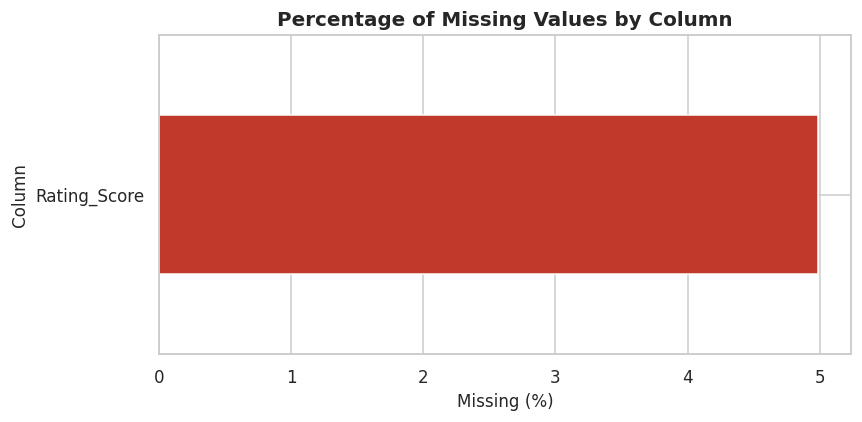

In [12]:
# -------------------------------------------------------------------
# Visualize Missing Values
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
missing_summary[missing_summary["Missing_Count"] > 0]["Missing_Percent"].plot(
    kind="barh", color="#C0392B", ax=ax
)
ax.set_title("Percentage of Missing Values by Column")
ax.set_xlabel("Missing (%)")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()


In [13]:
# -------------------------------------------------------------------
# Duplicate Records (fully identical rows)
# -------------------------------------------------------------------
n_duplicate_rows = df.duplicated().sum()
print(f"Fully duplicated rows: {n_duplicate_rows}")
df[df.duplicated(keep=False)].sort_values("CustomerID").head(10)


Fully duplicated rows: 15


,CustomerID,Age,Gender,Region,Income,Months_Subscribed,Total_Spend,Customer_Service_Calls,Rating_Score,Payment_Method,Churn
435,CUST-00436,40,Non-Binary,South,59675,23,1209.48,1,4.8,Bank Transfer,0
5008,CUST-00436,40,Non-Binary,South,59675,23,1209.48,1,4.8,Bank Transfer,0
980,CUST-00981,49,Male,West,50038,55,2062.95,1,5.0,PayPal,0
5005,CUST-00981,49,Male,West,50038,55,2062.95,1,5.0,PayPal,0
1715,CUST-01716,38,Male,South,86520,1,1667.37,0,4.4,Credit Card,0
5000,CUST-01716,38,Male,South,86520,1,1667.37,0,4.4,Credit Card,0
5014,CUST-01757,38,Female,West,83652,33,1053.63,2,4.8,Bank Transfer,0
1756,CUST-01757,38,Female,West,83652,33,1053.63,2,4.8,Bank Transfer,0
1878,CUST-01879,19,Male,South,67479,19,2019.30,1,3.2,PayPal,0
5004,CUST-01879,19,Male,South,67479,19,2019.30,1,3.2,PayPal,0


In [14]:
# -------------------------------------------------------------------
# Duplicate Customer IDs
# -------------------------------------------------------------------
n_duplicate_ids = df['CustomerID'].duplicated().sum()
print(f"Duplicate CustomerID entries: {n_duplicate_ids}")
df[df['CustomerID'].duplicated(keep=False)].sort_values('CustomerID').head(10)


Duplicate CustomerID entries: 15


,CustomerID,Age,Gender,Region,Income,Months_Subscribed,Total_Spend,Customer_Service_Calls,Rating_Score,Payment_Method,Churn
435,CUST-00436,40,Non-Binary,South,59675,23,1209.48,1,4.8,Bank Transfer,0
5008,CUST-00436,40,Non-Binary,South,59675,23,1209.48,1,4.8,Bank Transfer,0
980,CUST-00981,49,Male,West,50038,55,2062.95,1,5.0,PayPal,0
5005,CUST-00981,49,Male,West,50038,55,2062.95,1,5.0,PayPal,0
1715,CUST-01716,38,Male,South,86520,1,1667.37,0,4.4,Credit Card,0
5000,CUST-01716,38,Male,South,86520,1,1667.37,0,4.4,Credit Card,0
5014,CUST-01757,38,Female,West,83652,33,1053.63,2,4.8,Bank Transfer,0
1756,CUST-01757,38,Female,West,83652,33,1053.63,2,4.8,Bank Transfer,0
1878,CUST-01879,19,Male,South,67479,19,2019.30,1,3.2,PayPal,0
5004,CUST-01879,19,Male,South,67479,19,2019.30,1,3.2,PayPal,0


In [15]:
# -------------------------------------------------------------------
# Invalid Values — Negative Values in Columns That Should Be Non-Negative
# -------------------------------------------------------------------
non_negative_cols = ['Age', 'Income', 'Months_Subscribed', 'Total_Spend',
                      'Customer_Service_Calls', 'Rating_Score']

negative_summary = {}
for col in non_negative_cols:
    n_neg = (df[col] < 0).sum()
    negative_summary[col] = n_neg

negative_df = pd.DataFrame.from_dict(negative_summary, orient='index', columns=['Negative_Count'])
negative_df


,Negative_Count
Age,0
Income,8
Months_Subscribed,0
Total_Spend,0
Customer_Service_Calls,0
Rating_Score,0


In [16]:
# -------------------------------------------------------------------
# Incorrect / Inconsistent Categories
# -------------------------------------------------------------------
print("Unique Gender values:", sorted(df['Gender'].unique()))
print("Unique Region values:", sorted(df['Region'].unique()))
print("Unique Payment_Method values:", sorted(df['Payment_Method'].unique()))
print("Unique Churn values:", sorted(df['Churn'].unique()))


Unique Gender values: ['F', 'Female', 'M', 'Male', 'Non-Binary', 'female', 'male']
Unique Region values: ['East', 'North', 'South', 'West']
Unique Payment_Method values: ['Bank Transfer', 'Credit Card', 'PayPal']
Unique Churn values: [np.int64(0), np.int64(1)]


In [17]:
# -------------------------------------------------------------------
# Data Type Issues
# -------------------------------------------------------------------
expected_types = {
    'CustomerID': 'object', 'Age': 'int64', 'Gender': 'object', 'Region': 'object',
    'Income': 'int64', 'Months_Subscribed': 'int64', 'Total_Spend': 'float64',
    'Customer_Service_Calls': 'int64', 'Rating_Score': 'float64',
    'Payment_Method': 'object', 'Churn': 'int64'
}

type_check = pd.DataFrame({
    "Expected_Type": expected_types,
    "Actual_Type": df.dtypes.astype(str)
})
type_check["Match"] = type_check["Expected_Type"] == type_check["Actual_Type"]
type_check


,Expected_Type,Actual_Type,Match
CustomerID,object,str,False
Age,int64,int64,True
Gender,object,str,False
Region,object,str,False
Income,int64,int64,True
Months_Subscribed,int64,int64,True
Total_Spend,float64,float64,True
Customer_Service_Calls,int64,int64,True
Rating_Score,float64,float64,True
Payment_Method,object,str,False


In [18]:
# -------------------------------------------------------------------
# Outlier Overview (IQR method) for key numerical columns
# -------------------------------------------------------------------
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_cols = ['Age', 'Income', 'Months_Subscribed', 'Total_Spend', 'Customer_Service_Calls']
outlier_overview = pd.DataFrame({
    "Column": outlier_cols,
    "Outlier_Count_IQR": [iqr_outlier_count(df[c].dropna()) for c in outlier_cols]
})
outlier_overview


,Column,Outlier_Count_IQR
0,Age,30
1,Income,34
2,Months_Subscribed,0
3,Total_Spend,9
4,Customer_Service_Calls,308


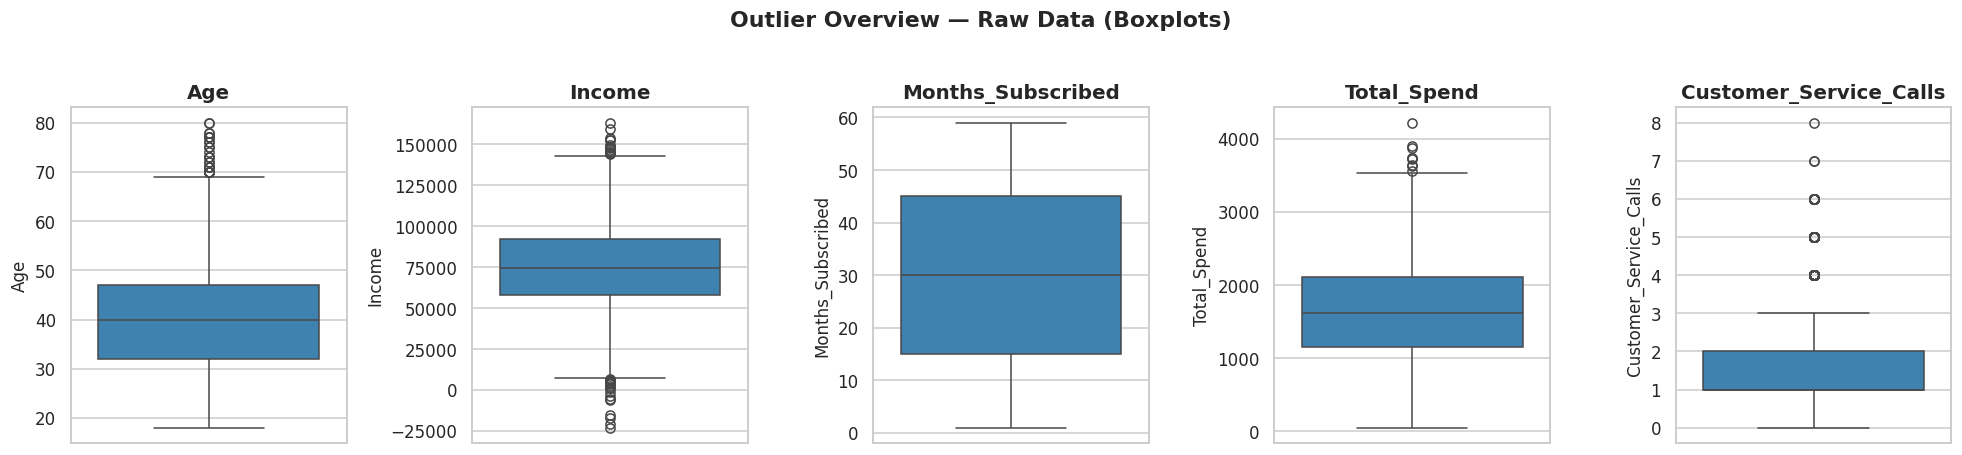

In [19]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#2E86C1")
    ax.set_title(col)
fig.suptitle("Outlier Overview — Raw Data (Boxplots)", y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()


In [20]:
# -------------------------------------------------------------------
# Data Quality Assessment Summary
# -------------------------------------------------------------------
quality_summary = pd.DataFrame({
    "Issue": [
        "Missing Rating_Score",
        "Fully duplicated rows",
        "Duplicate CustomerIDs",
        "Negative Income values",
        "Inconsistent Gender categories",
        "Outliers in Income (IQR)",
        "Outliers in Total_Spend (IQR)"
    ],
    "Count": [
        df['Rating_Score'].isnull().sum(),
        n_duplicate_rows,
        n_duplicate_ids,
        (df['Income'] < 0).sum(),
        df['Gender'].nunique() - 2,   # expected ~2-3 clean categories
        iqr_outlier_count(df['Income'].dropna()),
        iqr_outlier_count(df['Total_Spend'].dropna())
    ]
})
quality_summary


,Issue,Count
0,Missing Rating_Score,250
1,Fully duplicated rows,15
2,Duplicate CustomerIDs,15
3,Negative Income values,8
4,Inconsistent Gender categories,5
5,Outliers in Income (IQR),34
6,Outliers in Total_Spend (IQR),9


### Business Interpretation — Data Quality Assessment

- **Missing `Rating_Score` values** (roughly 5% of records) likely correspond to customers who never submitted a satisfaction survey — this is a *missing-not-completely-at-random* pattern common in voluntary feedback systems, and will be imputed rather than dropped to avoid losing valuable churn/spend signal.
- **Duplicate rows and duplicate CustomerIDs** point to accidental double-loading of some records during data extraction — these must be removed before analysis to avoid inflating sample size and biasing statistics.
- **Negative Income values** are logically impossible and almost certainly a data-entry or sign error — these will be treated as missing and imputed.
- **Inconsistent Gender labels** (e.g. mixed casing and abbreviations) will inflate the apparent number of categories and fragment group-level analysis if left unstandardized.
- **Outliers in Income and Total_Spend** are expected in real customer populations (high-income or high-spend customers exist legitimately) — we will inspect rather than blindly remove them, since they may represent Zephyr's most valuable customers.

These findings define the exact cleaning steps executed in Module 4.


---
# Module 4 — Data Preprocessing

We now systematically clean the dataset based on the issues identified in Module 3. Every transformation is applied to a working copy (`df_clean`) so the original raw data remains available for audit.


In [21]:
df_clean = df.copy()
print(f"Starting shape: {df_clean.shape}")


Starting shape: (5015, 11)


In [22]:
# -------------------------------------------------------------------
# Remove Fully Duplicate Records
# -------------------------------------------------------------------
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Removed {before - after} fully duplicated rows. New shape: {df_clean.shape}")


Removed 15 fully duplicated rows. New shape: (5000, 11)


In [23]:
# -------------------------------------------------------------------
# Remove Duplicate Customer IDs (keep first occurrence)
# -------------------------------------------------------------------
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='CustomerID', keep='first')
after = len(df_clean)
print(f"Removed {before - after} duplicate CustomerID rows. New shape: {df_clean.shape}")


Removed 0 duplicate CustomerID rows. New shape: (5000, 11)


In [24]:
# -------------------------------------------------------------------
# Standardize Gender
# -------------------------------------------------------------------
gender_map = {
    'F': 'Female', 'female': 'Female', 'Female': 'Female',
    'M': 'Male', 'male': 'Male', 'Male': 'Male',
    'Non-Binary': 'Non-Binary'
}
df_clean['Gender'] = df_clean['Gender'].map(gender_map).fillna(df_clean['Gender'])
print("Standardized Gender categories:", sorted(df_clean['Gender'].unique()))


Standardized Gender categories: ['Female', 'Male', 'Non-Binary']


In [25]:
# -------------------------------------------------------------------
# Standardize Region
# -------------------------------------------------------------------
df_clean['Region'] = df_clean['Region'].str.strip().str.title()
print("Standardized Region categories:", sorted(df_clean['Region'].unique()))


Standardized Region categories: ['East', 'North', 'South', 'West']


In [26]:
# -------------------------------------------------------------------
# Standardize Payment Method
# -------------------------------------------------------------------
df_clean['Payment_Method'] = df_clean['Payment_Method'].str.strip().str.title()
print("Standardized Payment_Method categories:", sorted(df_clean['Payment_Method'].unique()))


Standardized Payment_Method categories: ['Bank Transfer', 'Credit Card', 'Paypal']


In [27]:
# -------------------------------------------------------------------
# Replace Negative Income with NaN, then Impute using Median
# -------------------------------------------------------------------
n_negative = (df_clean['Income'] < 0).sum()
df_clean.loc[df_clean['Income'] < 0, 'Income'] = np.nan
print(f"Flagged {n_negative} negative Income values as missing.")

income_median = df_clean['Income'].median()
df_clean['Income'] = df_clean['Income'].fillna(income_median)
print(f"Imputed missing Income with median value: {income_median:,.0f}")


Flagged 8 negative Income values as missing.
Imputed missing Income with median value: 74,604


In [28]:
# -------------------------------------------------------------------
# Handle Missing Rating Scores (impute with median, grouped by Churn)
# -------------------------------------------------------------------
n_missing_rating = df_clean['Rating_Score'].isnull().sum()
df_clean['Rating_Score'] = df_clean.groupby('Churn')['Rating_Score'].transform(
    lambda x: x.fillna(x.median())
)
print(f"Imputed {n_missing_rating} missing Rating_Score values using churn-group median.")


Imputed 250 missing Rating_Score values using churn-group median.


In [29]:
# -------------------------------------------------------------------
# Convert Data Types
# -------------------------------------------------------------------
df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['Income'] = df_clean['Income'].astype(float)
df_clean['Months_Subscribed'] = df_clean['Months_Subscribed'].astype(int)
df_clean['Total_Spend'] = df_clean['Total_Spend'].astype(float)
df_clean['Customer_Service_Calls'] = df_clean['Customer_Service_Calls'].astype(int)
df_clean['Rating_Score'] = df_clean['Rating_Score'].astype(float)
df_clean['Churn'] = df_clean['Churn'].astype(int)
df_clean['Gender'] = df_clean['Gender'].astype('category')
df_clean['Region'] = df_clean['Region'].astype('category')
df_clean['Payment_Method'] = df_clean['Payment_Method'].astype('category')

df_clean.dtypes.to_frame(name="Data Type")


,Data Type
CustomerID,str
Age,int64
Gender,category
Region,category
Income,float64
Months_Subscribed,int64
Total_Spend,float64
Customer_Service_Calls,int64
Rating_Score,float64
Payment_Method,category


In [30]:
# -------------------------------------------------------------------
# Validate Numerical Columns (plausible business ranges)
# -------------------------------------------------------------------
validation_checks = {
    "Age between 18 and 100": df_clean['Age'].between(18, 100).all(),
    "Income non-negative": (df_clean['Income'] >= 0).all(),
    "Months_Subscribed non-negative": (df_clean['Months_Subscribed'] >= 0).all(),
    "Total_Spend non-negative": (df_clean['Total_Spend'] >= 0).all(),
    "Customer_Service_Calls non-negative": (df_clean['Customer_Service_Calls'] >= 0).all(),
    "Rating_Score between 0 and 5": df_clean['Rating_Score'].between(0, 5).all(),
}
pd.Series(validation_checks, name="Passed").to_frame()


,Passed
Age between 18 and 100,True
Income non-negative,True
Months_Subscribed non-negative,True
Total_Spend non-negative,True
Customer_Service_Calls non-negative,True
Rating_Score between 0 and 5,True


In [31]:
# -------------------------------------------------------------------
# Validate Target Variable
# -------------------------------------------------------------------
print("Churn value counts:")
print(df_clean['Churn'].value_counts())
print(f"\nChurn rate: {df_clean['Churn'].mean() * 100:.2f}%")
assert set(df_clean['Churn'].unique()) == {0, 1}, "Churn must be binary (0/1)."
print("\nTarget variable validated: binary 0/1 as expected.")


Churn value counts:
Churn
0    4782
1     218
Name: count, dtype: int64

Churn rate: 4.36%

Target variable validated: binary 0/1 as expected.


In [32]:
# -------------------------------------------------------------------
# Check Final Missing Values
# -------------------------------------------------------------------
final_missing = df_clean.isnull().sum()
print("Remaining missing values per column:")
print(final_missing[final_missing > 0] if final_missing.sum() > 0 else "None — dataset is fully complete.")


Remaining missing values per column:
None — dataset is fully complete.


In [33]:
# -------------------------------------------------------------------
# Check Final Duplicates
# -------------------------------------------------------------------
print(f"Remaining fully duplicated rows: {df_clean.duplicated().sum()}")
print(f"Remaining duplicate CustomerIDs: {df_clean['CustomerID'].duplicated().sum()}")


Remaining fully duplicated rows: 0
Remaining duplicate CustomerIDs: 0


In [34]:
# -------------------------------------------------------------------
# Save Clean Dataset
# -------------------------------------------------------------------
df_clean = df_clean.reset_index(drop=True)
df_clean.to_csv("zephyr_customer_data_clean.csv", index=False)
print(f"Clean dataset saved. Final shape: {df_clean.shape}")
df_clean.head()


Clean dataset saved. Final shape: (5000, 11)


,CustomerID,Age,Gender,Region,Income,Months_Subscribed,Total_Spend,Customer_Service_Calls,Rating_Score,Payment_Method,Churn
0,CUST-00001,45,Female,North,64406.0,42,2407.72,4,2.5,Paypal,0
1,CUST-00002,38,Male,East,63664.0,56,2420.02,3,3.9,Credit Card,0
2,CUST-00003,47,Male,West,30108.0,17,1545.50,0,5.0,Paypal,0
3,CUST-00004,58,Male,North,66747.0,31,2055.80,3,5.0,Credit Card,0
4,CUST-00005,37,Female,North,93320.0,53,2369.31,0,3.8,Paypal,0


### Business Summary — Data Preprocessing

Starting from ~5,000 raw records, we removed duplicate rows and duplicate customer IDs, standardized inconsistent category labels (Gender, Region, Payment_Method), corrected impossible negative Income values via median imputation, and filled missing satisfaction ratings using churn-group medians (so imputation does not artificially wash out the Churn/Rating relationship). All data types were validated and the target variable confirmed binary and clean.

The result is `df_clean` — a fully validated, analysis-ready dataset with **no missing values, no duplicates, and no invalid entries**, saved to `zephyr_customer_data_clean.csv` for reproducibility.


---
# Module 5 — Exploratory Data Analysis (EDA)

With a clean dataset in hand, we now explore the distribution and shape of each variable to build intuition before formal hypothesis testing and modeling.


In [35]:
numerical_cols = ['Age', 'Income', 'Months_Subscribed', 'Total_Spend',
                   'Customer_Service_Calls', 'Rating_Score']
categorical_cols = ['Gender', 'Region', 'Payment_Method']

df_clean[numerical_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,39.750000,11.557033,18.0,32.000,40.000,47.000,80.00
Income,5000.0,74890.493200,25021.515589,1143.0,57907.500,74604.000,91930.250,163226.00
Months_Subscribed,5000.0,29.861800,17.117433,1.0,15.000,30.000,45.000,59.00
Total_Spend,5000.0,1626.186004,684.708447,50.0,1150.325,1622.715,2108.725,4217.71
Customer_Service_Calls,5000.0,1.502200,1.210904,0.0,1.000,1.000,2.000,8.00
Rating_Score,5000.0,3.906380,0.849024,1.0,3.300,4.000,4.700,5.00


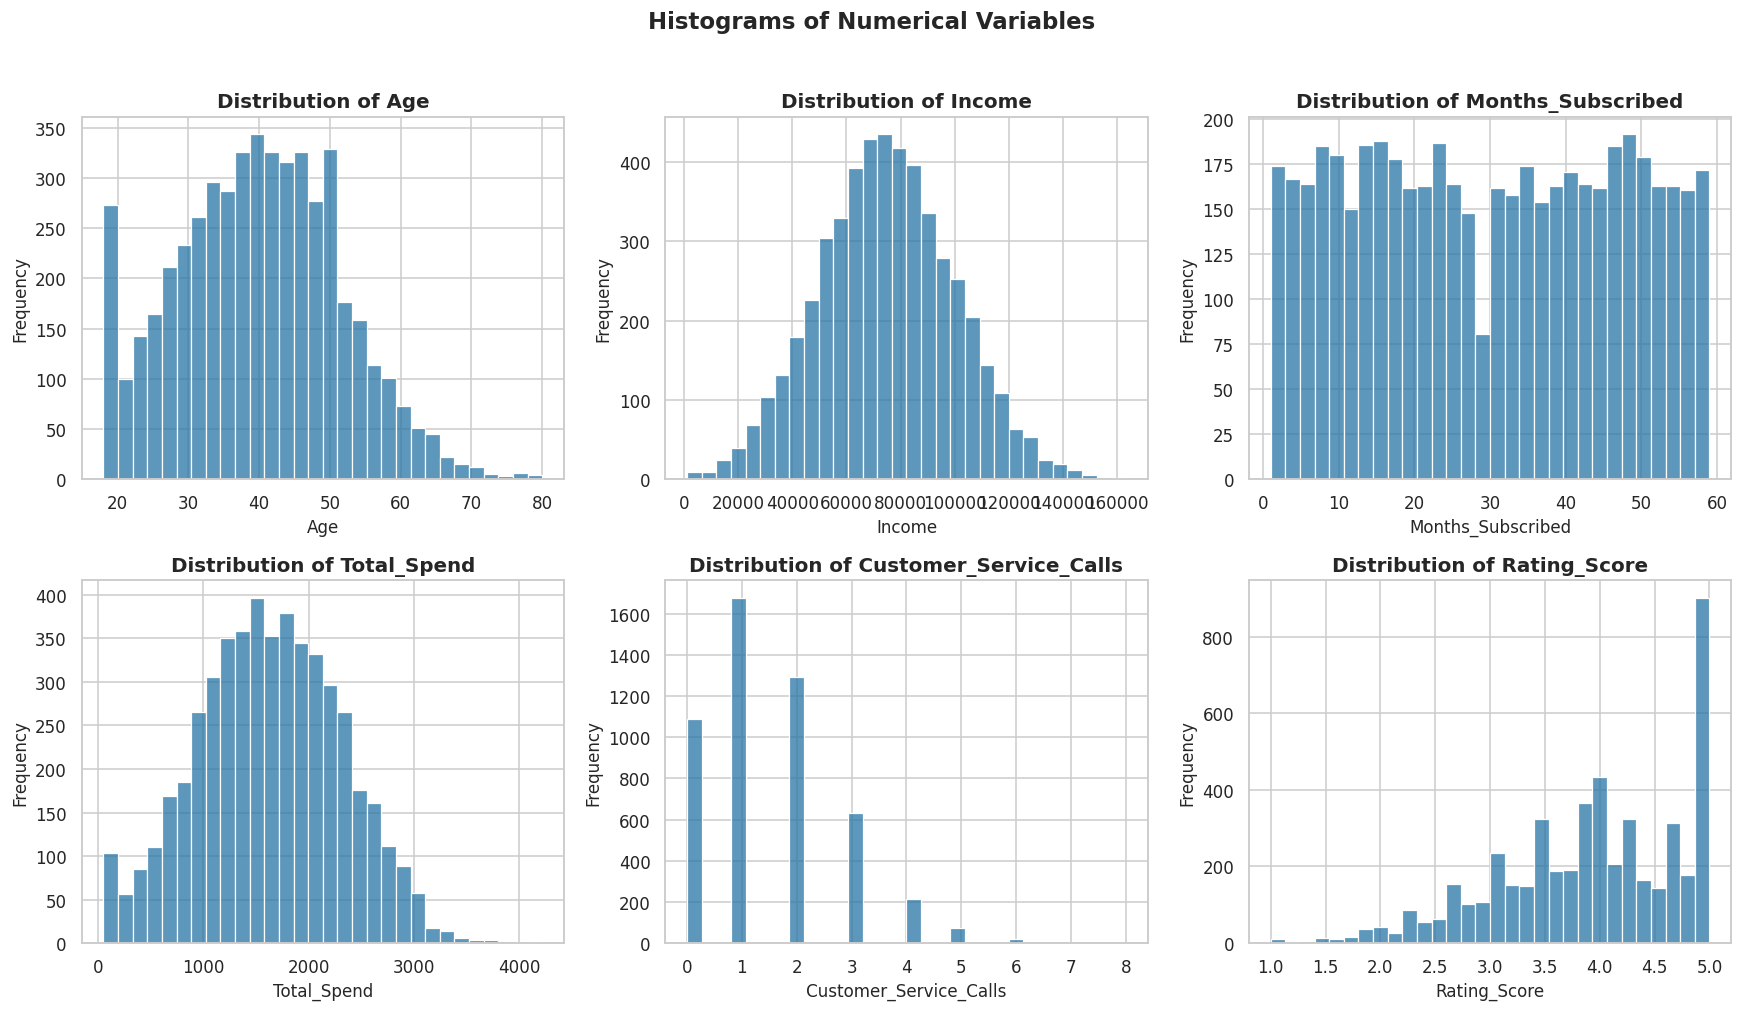

In [36]:
# -------------------------------------------------------------------
# Histograms — Numerical Variables
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, numerical_cols):
    sns.histplot(df_clean[col], bins=30, kde=False, color="#2874A6", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
fig.suptitle("Histograms of Numerical Variables", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Business Interpretation:** `Age` and `Income` are broadly spread across a realistic adult customer base. `Total_Spend` and `Months_Subscribed` are right-skewed — most customers spend moderately and subscribe for a shorter tenure, with a smaller group of long-tenured, high-spend customers. `Customer_Service_Calls` is concentrated at low values, suggesting most customers rarely need support, while a smaller group calls frequently — a potential churn signal.

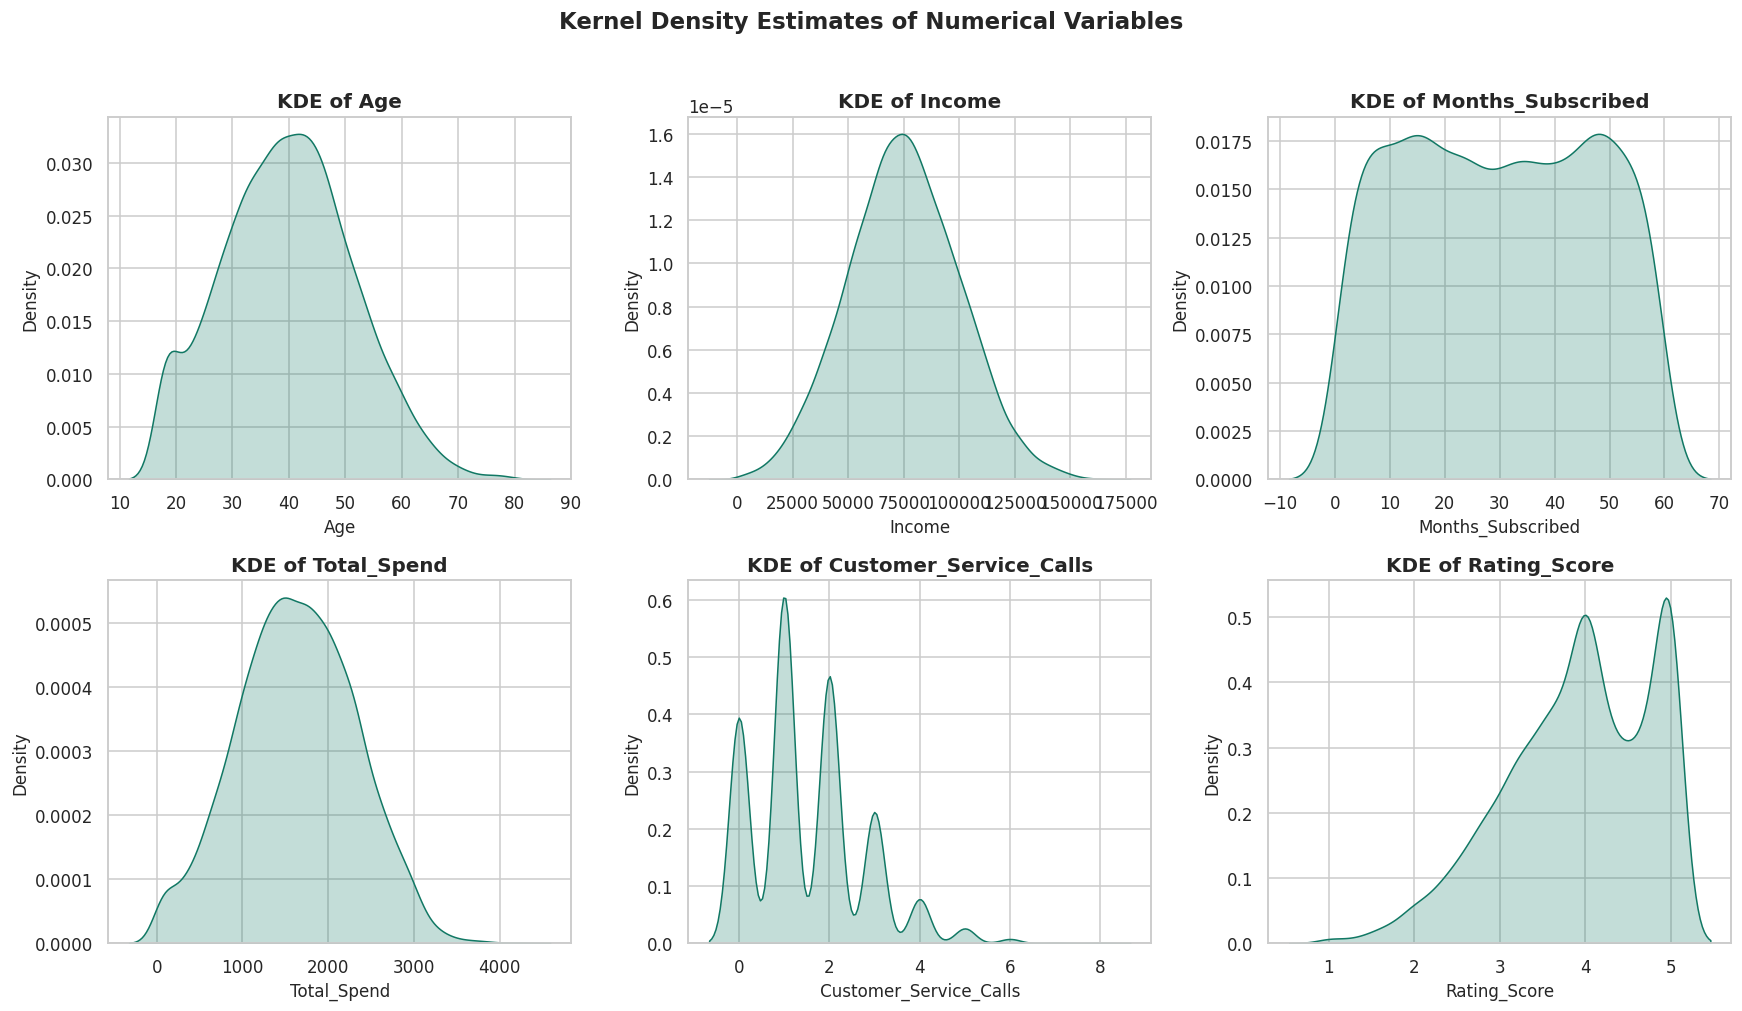

In [37]:
# -------------------------------------------------------------------
# KDE Plots — Numerical Variables
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, numerical_cols):
    sns.kdeplot(df_clean[col], fill=True, color="#117864", ax=ax)
    ax.set_title(f"KDE of {col}")
fig.suptitle("Kernel Density Estimates of Numerical Variables", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Business Interpretation:** The KDE curves confirm the histogram shapes with smoother detail — `Income` and `Age` are approximately unimodal and moderately symmetric, while `Total_Spend` shows a long right tail, meaning average spend figures alone can be misleading; median-based reporting is more representative for CLV discussions with leadership.

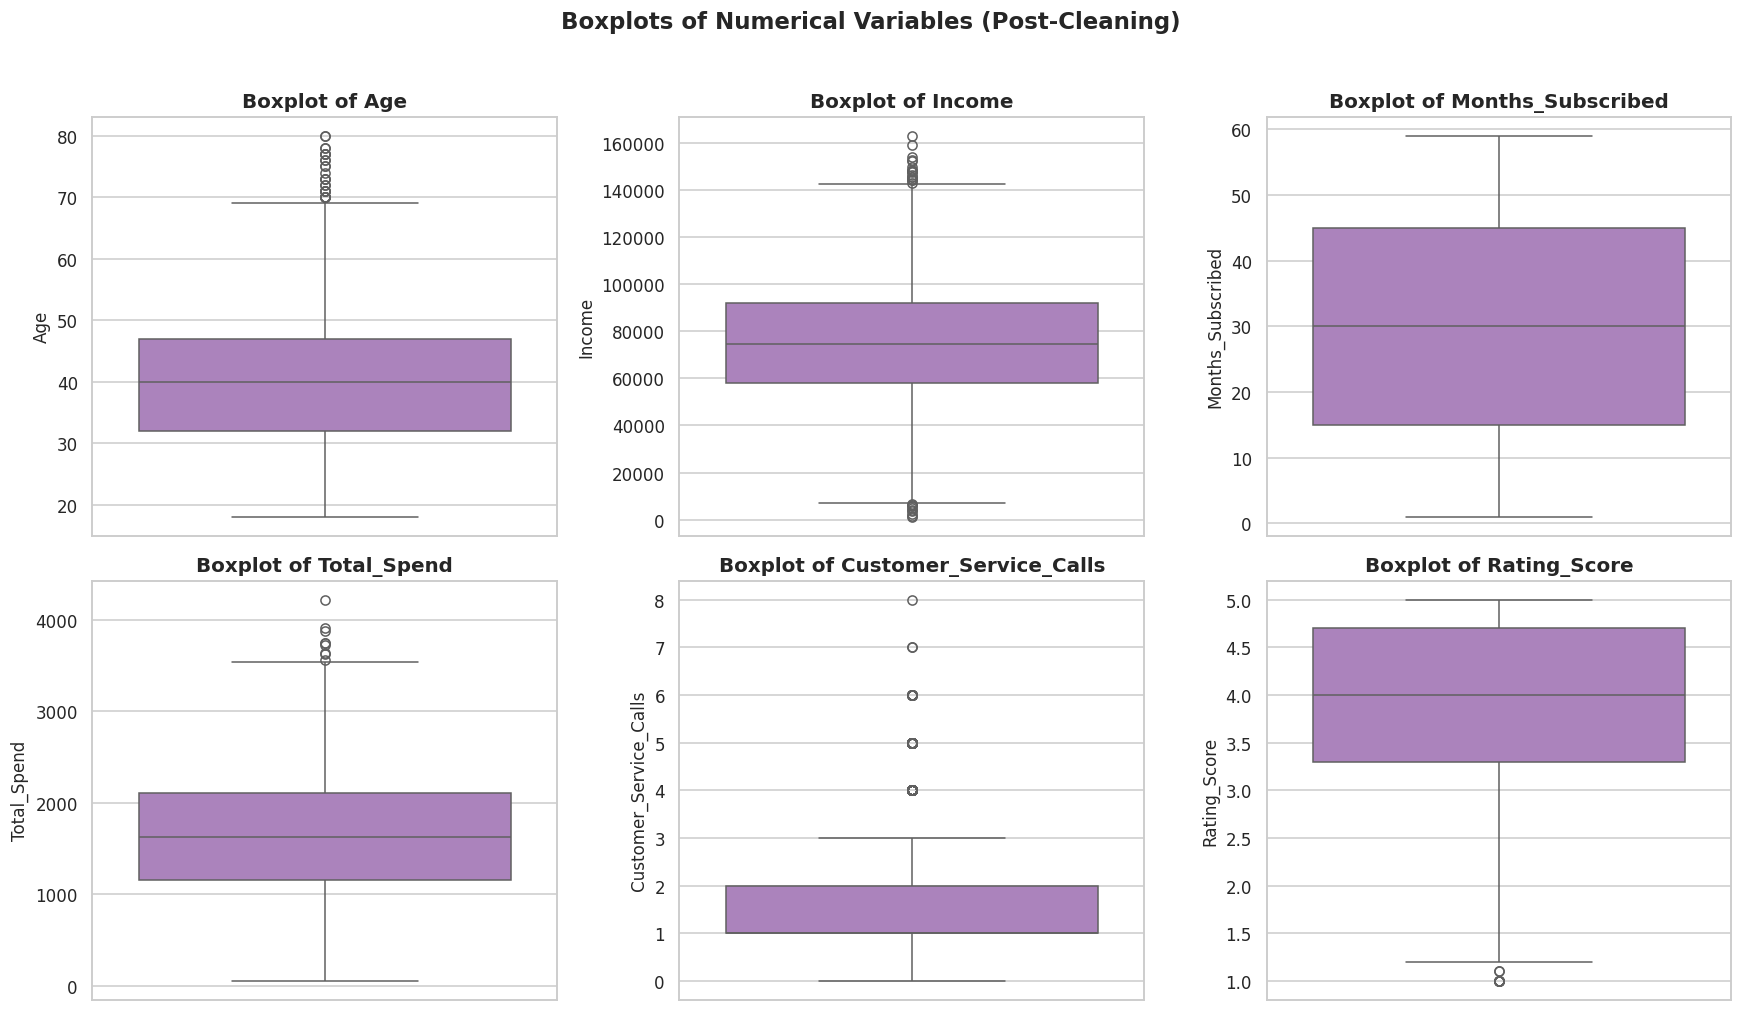

In [38]:
# -------------------------------------------------------------------
# Boxplots — Numerical Variables
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(y=df_clean[col], color="#AF7AC5", ax=ax)
    ax.set_title(f"Boxplot of {col}")
fig.suptitle("Boxplots of Numerical Variables (Post-Cleaning)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Business Interpretation:** Post-cleaning, the boxplots show a small number of legitimate high-Income and high-Total_Spend customers. These are not data errors — they represent Zephyr's premium customer segment and should be preserved for the CLV model rather than removed as outliers.

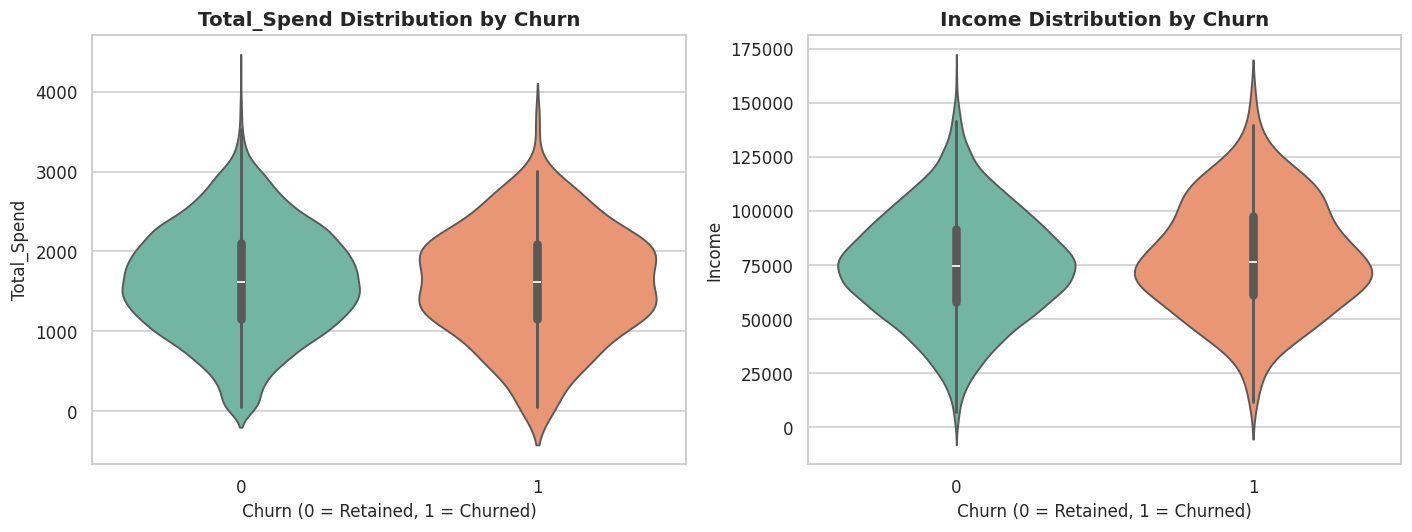

In [39]:
# -------------------------------------------------------------------
# Violin Plots — Total_Spend and Income by Churn
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(x='Churn', y='Total_Spend', data=df_clean, ax=axes[0], palette="Set2")
axes[0].set_title("Total_Spend Distribution by Churn")
axes[0].set_xlabel("Churn (0 = Retained, 1 = Churned)")

sns.violinplot(x='Churn', y='Income', data=df_clean, ax=axes[1], palette="Set2")
axes[1].set_title("Income Distribution by Churn")
axes[1].set_xlabel("Churn (0 = Retained, 1 = Churned)")
plt.tight_layout()
plt.show()


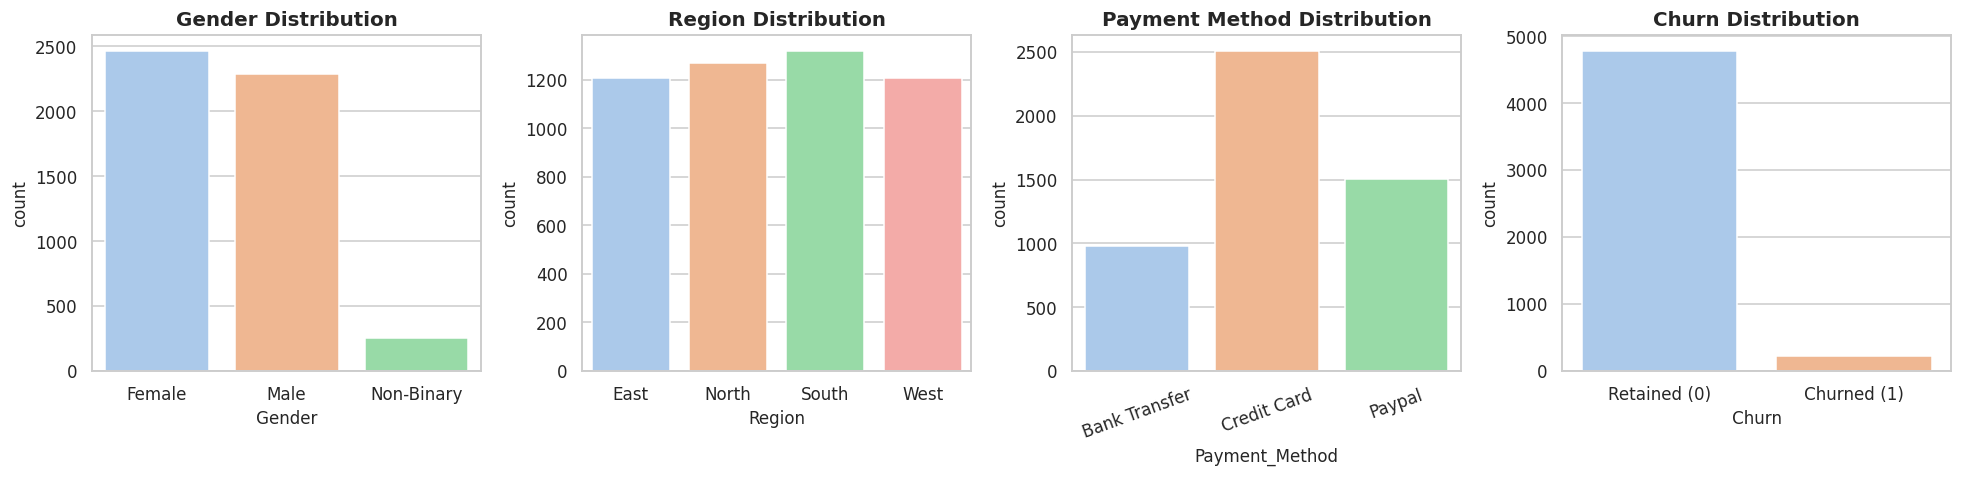

In [40]:
# -------------------------------------------------------------------
# Countplots — Categorical Variables
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
sns.countplot(x='Gender', data=df_clean, ax=axes[0], palette="pastel")
axes[0].set_title("Gender Distribution")

sns.countplot(x='Region', data=df_clean, ax=axes[1], palette="pastel")
axes[1].set_title("Region Distribution")

sns.countplot(x='Payment_Method', data=df_clean, ax=axes[2], palette="pastel")
axes[2].set_title("Payment Method Distribution")
axes[2].tick_params(axis='x', rotation=20)

sns.countplot(x='Churn', data=df_clean, ax=axes[3], palette="pastel")
axes[3].set_title("Churn Distribution")
axes[3].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()


**Business Interpretation:** The customer base is fairly balanced across regions and payment methods, giving confidence that regional or payment-method findings will generalize. The Churn distribution shows a minority-class churn pattern typical of subscription businesses — important to keep in mind when evaluating classification model performance in Module 11 (accuracy alone can be misleading with class imbalance).

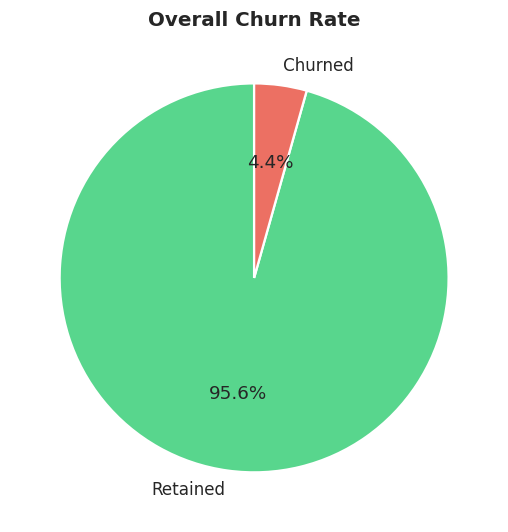

In [41]:
# -------------------------------------------------------------------
# Pie Chart — Churn Proportion (appropriate for a 2-category share-of-whole view)
# -------------------------------------------------------------------
churn_counts = df_clean['Churn'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
    colors=['#58D68D', '#EC7063'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title("Overall Churn Rate")
plt.tight_layout()
plt.show()


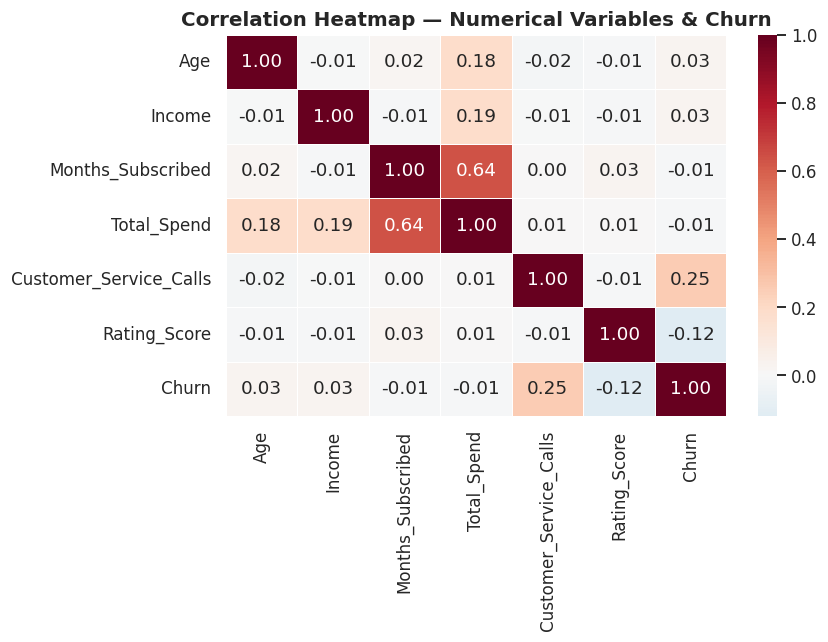

In [42]:
# -------------------------------------------------------------------
# Correlation Heatmap
# -------------------------------------------------------------------
corr_matrix = df_clean[numerical_cols + ['Churn']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Numerical Variables & Churn")
plt.tight_layout()
plt.show()


**Business Interpretation:** `Customer_Service_Calls` shows the strongest positive correlation with `Churn`, reinforcing that service friction is a leading churn driver. `Months_Subscribed` and `Total_Spend` correlate positively with each other (tenure builds spend) and negatively with `Churn`, confirming that longer-tenured, higher-spending customers are more loyal. No pair of predictors shows extreme multicollinearity (|r| > 0.9), so all variables can reasonably be considered for modeling — this is verified formally with VIF in Module 9.

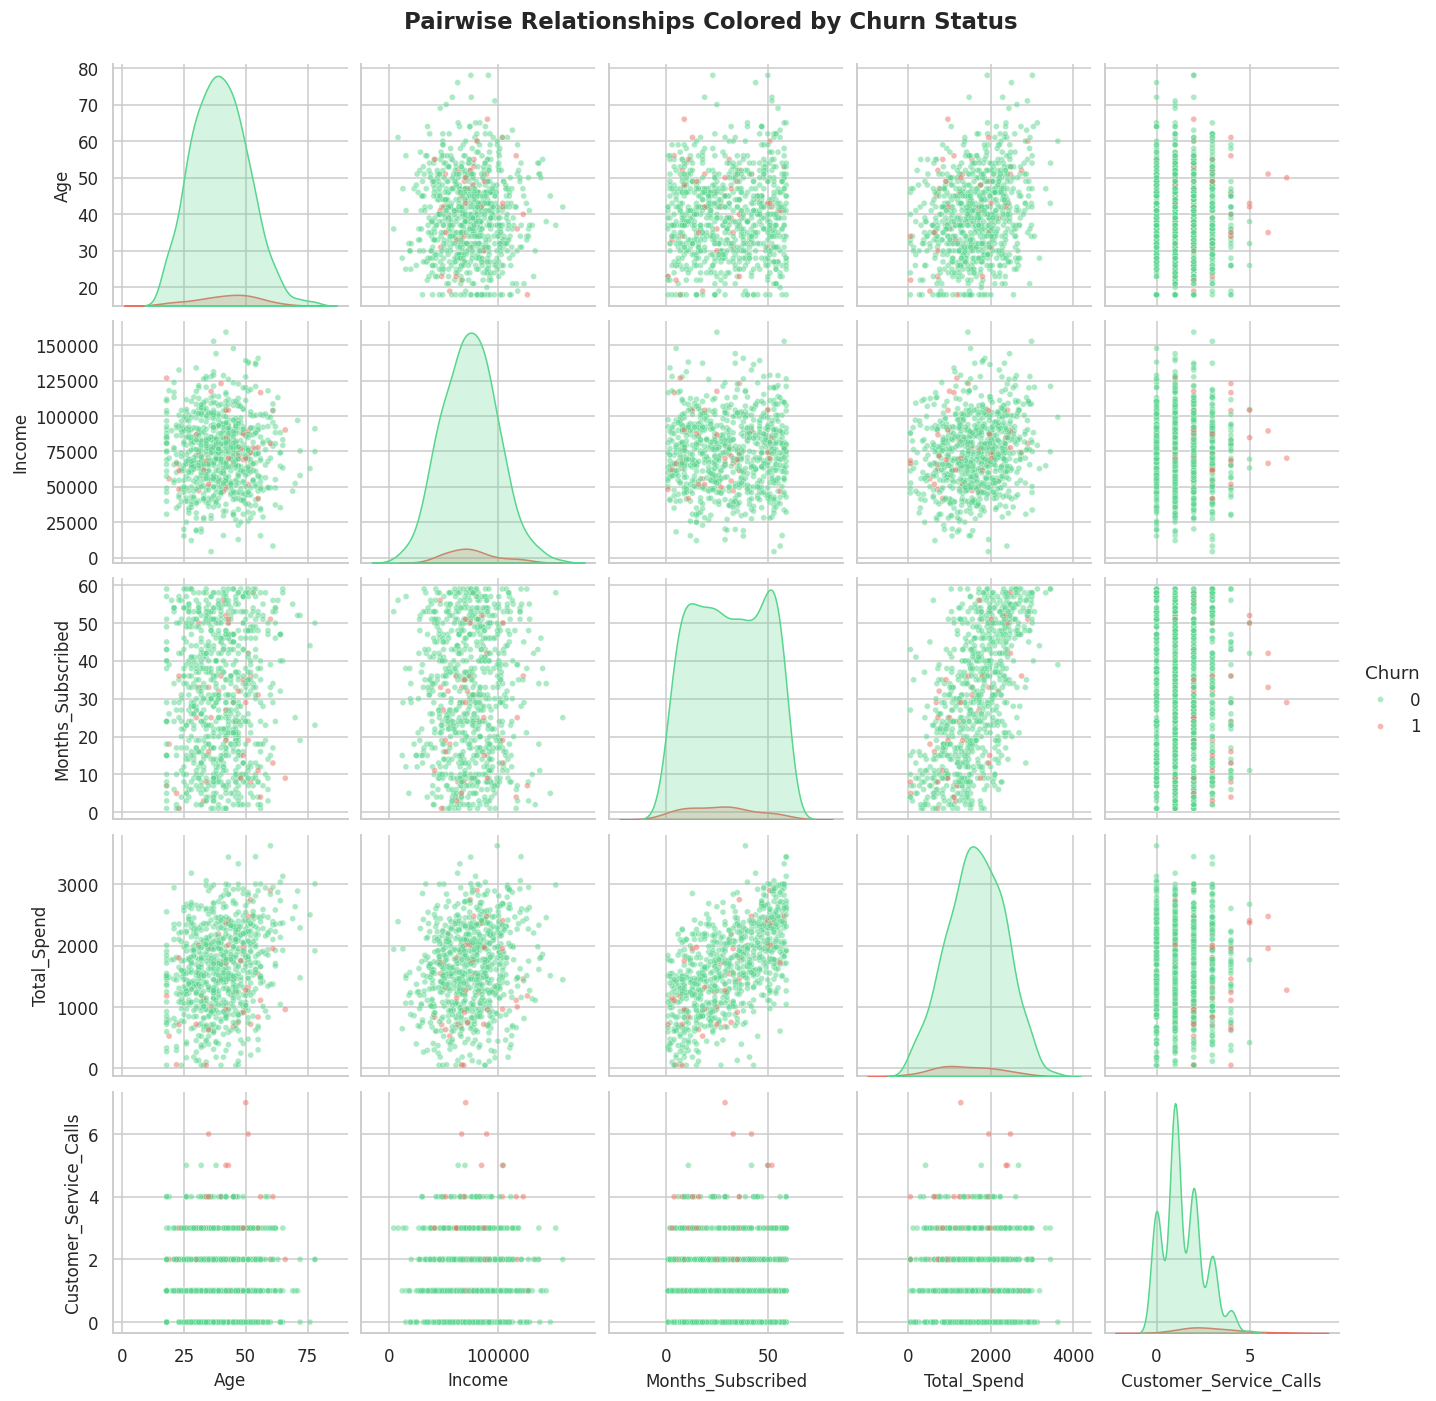

In [43]:
# -------------------------------------------------------------------
# Pairplot — Numerical Variables Colored by Churn
# -------------------------------------------------------------------
pairplot_sample = df_clean.sample(n=min(800, len(df_clean)), random_state=RANDOM_STATE)
g = sns.pairplot(
    pairplot_sample,
    vars=['Age', 'Income', 'Months_Subscribed', 'Total_Spend', 'Customer_Service_Calls'],
    hue='Churn', palette={0: '#58D68D', 1: '#EC7063'}, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15}
)
g.fig.suptitle("Pairwise Relationships Colored by Churn Status", y=1.02, fontsize=15, fontweight='bold')
plt.show()


**Business Interpretation:** Churned customers (red) visibly cluster toward lower `Months_Subscribed` and lower `Total_Spend`, and are somewhat more spread toward higher `Customer_Service_Calls` — a visual preview of the churn drivers that will be statistically confirmed in Modules 6 and 7.

In [44]:
# -------------------------------------------------------------------
# Distribution Analysis — Skewness and Kurtosis
# -------------------------------------------------------------------
skew_kurt = pd.DataFrame({
    "Skewness": df_clean[numerical_cols].skew(),
    "Kurtosis": df_clean[numerical_cols].kurt()
}).round(3)
skew_kurt


,Skewness,Kurtosis
Age,0.165,-0.306
Income,0.067,-0.109
Months_Subscribed,0.010,-1.227
Total_Spend,0.008,-0.328
Customer_Service_Calls,0.808,0.691
Rating_Score,-0.568,-0.227


**Business Interpretation:** `Total_Spend` and `Months_Subscribed` show positive (right) skew, confirming most customers cluster at lower-to-moderate values with a long tail of high-value customers. Kurtosis values close to 0 indicate roughly normal tail thickness for `Age` and `Income`, while `Customer_Service_Calls` shows higher kurtosis, consistent with a concentrated majority of low-call customers and a distinct minority of high-call, high-friction customers — a group worth targeting operationally.

---
# Module 6 — Bivariate & Multivariate Analysis

This module examines each predictor's relationship with `Churn` in more detail, along with cross-tabulations and grouped statistics.


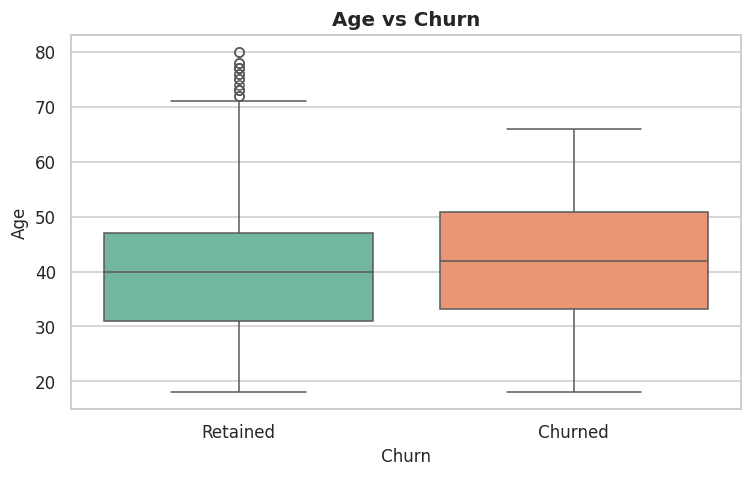

        mean  median    std
Churn                      
0      39.67    40.0  11.54
1      41.42    42.0  11.74


In [45]:
# -------------------------------------------------------------------
# Age vs Churn
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(x='Churn', y='Age', data=df_clean, palette="Set2", ax=ax)
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_title("Age vs Churn")
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn')['Age'].agg(['mean', 'median', 'std']).round(2))


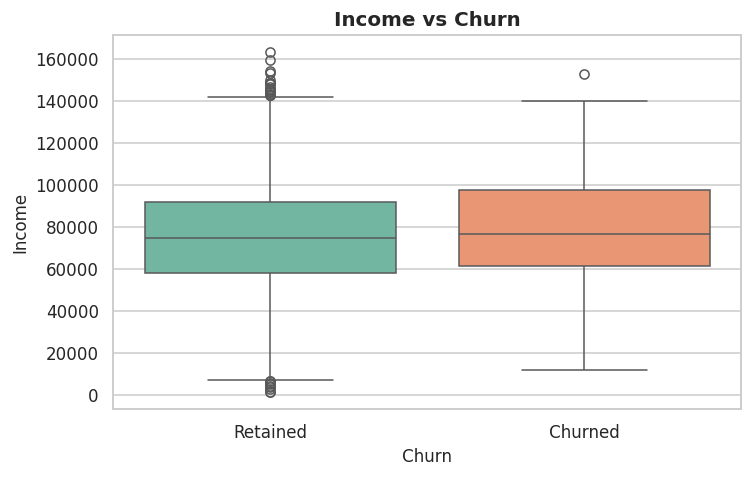

           mean   median       std
Churn                             
0      74721.15  74604.0  24992.50
1      78605.12  76282.0  25425.26


In [46]:
# -------------------------------------------------------------------
# Income vs Churn
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(x='Churn', y='Income', data=df_clean, palette="Set2", ax=ax)
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_title("Income vs Churn")
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn')['Income'].agg(['mean', 'median', 'std']).round(2))


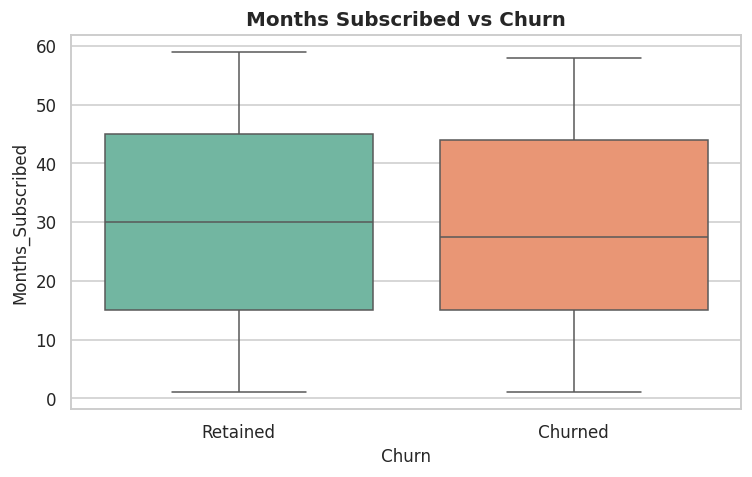

        mean  median    std
Churn                      
0      29.91    30.0  17.13
1      28.75    27.5  16.90


In [47]:
# -------------------------------------------------------------------
# Months Subscribed vs Churn
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(x='Churn', y='Months_Subscribed', data=df_clean, palette="Set2", ax=ax)
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_title("Months Subscribed vs Churn")
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn')['Months_Subscribed'].agg(['mean', 'median', 'std']).round(2))


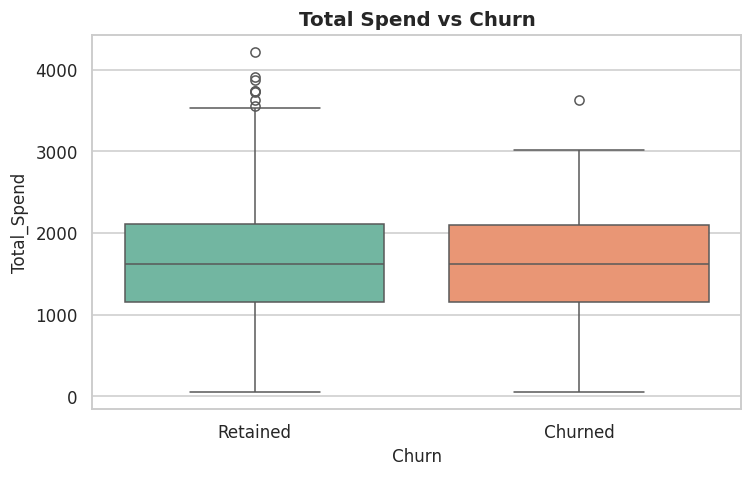

          mean   median     std
Churn                          
0      1627.84  1623.04  684.38
1      1589.82  1615.87  692.54


In [48]:
# -------------------------------------------------------------------
# Total Spend vs Churn
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(x='Churn', y='Total_Spend', data=df_clean, palette="Set2", ax=ax)
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_title("Total Spend vs Churn")
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn')['Total_Spend'].agg(['mean', 'median', 'std']).round(2))


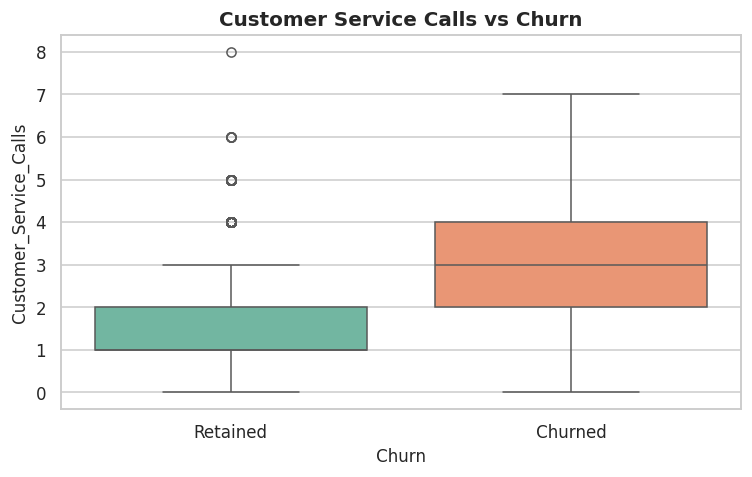

       mean  median   std
Churn                    
0      1.44     1.0  1.15
1      2.93     3.0  1.57


In [49]:
# -------------------------------------------------------------------
# Customer Service Calls vs Churn
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(x='Churn', y='Customer_Service_Calls', data=df_clean, palette="Set2", ax=ax)
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_title("Customer Service Calls vs Churn")
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn')['Customer_Service_Calls'].agg(['mean', 'median', 'std']).round(2))


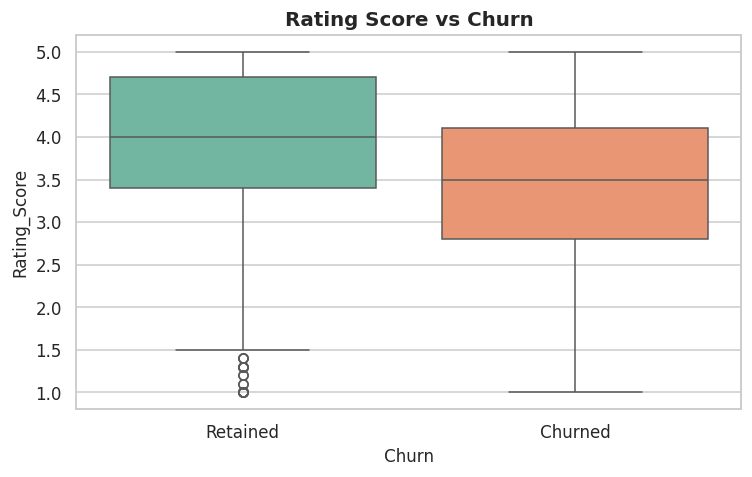

       mean  median   std
Churn                    
0      3.93     4.0  0.84
1      3.43     3.5  0.92


In [50]:
# -------------------------------------------------------------------
# Rating Score vs Churn
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(x='Churn', y='Rating_Score', data=df_clean, palette="Set2", ax=ax)
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_title("Rating Score vs Churn")
plt.tight_layout()
plt.show()

print(df_clean.groupby('Churn')['Rating_Score'].agg(['mean', 'median', 'std']).round(2))


            Retained (%)  Churned (%)
Gender                               
Female             95.50         4.50
Male               95.67         4.33
Non-Binary         96.80         3.20


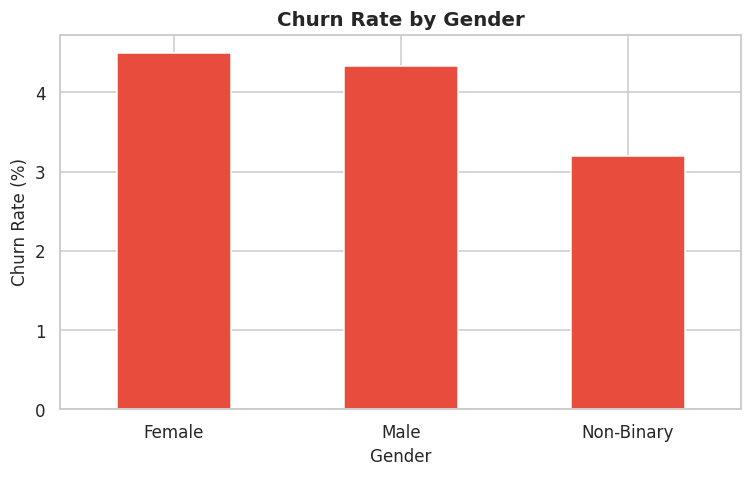

In [51]:
# -------------------------------------------------------------------
# Gender vs Churn
# -------------------------------------------------------------------
gender_churn = pd.crosstab(df_clean['Gender'], df_clean['Churn'], normalize='index') * 100
gender_churn.columns = ['Retained (%)', 'Churned (%)']
print(gender_churn.round(2))

fig, ax = plt.subplots(figsize=(7, 4.5))
gender_churn['Churned (%)'].plot(kind='bar', color="#E74C3C", ax=ax)
ax.set_title("Churn Rate by Gender")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


        Retained (%)  Churned (%)
Region                           
East           95.77         4.23
North          94.96         5.04
South          96.21         3.79
West           95.61         4.39


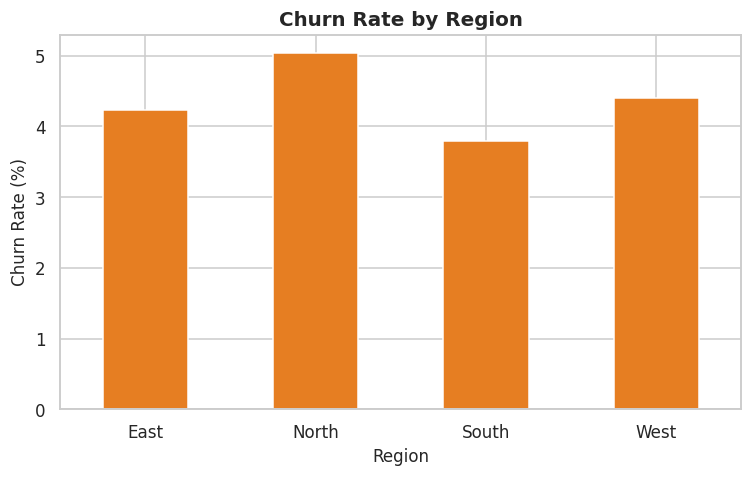

In [52]:
# -------------------------------------------------------------------
# Region vs Churn
# -------------------------------------------------------------------
region_churn = pd.crosstab(df_clean['Region'], df_clean['Churn'], normalize='index') * 100
region_churn.columns = ['Retained (%)', 'Churned (%)']
print(region_churn.round(2))

fig, ax = plt.subplots(figsize=(7, 4.5))
region_churn['Churned (%)'].plot(kind='bar', color="#E67E22", ax=ax)
ax.set_title("Churn Rate by Region")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


                Retained (%)  Churned (%)
Payment_Method                           
Bank Transfer          96.13         3.87
Credit Card            95.54         4.46
Paypal                 95.49         4.51

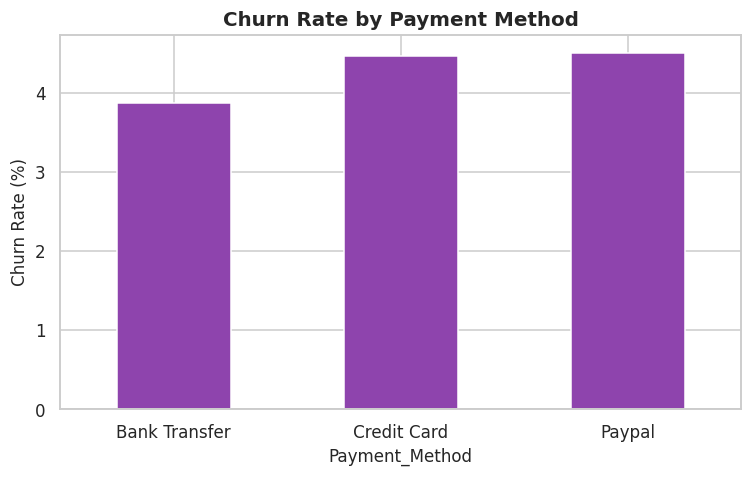

In [53]:
# -------------------------------------------------------------------
# Payment Method vs Churn
# -------------------------------------------------------------------
payment_churn = pd.crosstab(df_clean['Payment_Method'], df_clean['Churn'], normalize='index') * 100
payment_churn.columns = ['Retained (%)', 'Churned (%)']
print(payment_churn.round(2))

fig, ax = plt.subplots(figsize=(7, 4.5))
payment_churn['Churned (%)'].plot(kind='bar', color="#8E44AD", ax=ax)
ax.set_title("Churn Rate by Payment Method")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [54]:
# -------------------------------------------------------------------
# Cross Tabs — Region x Payment Method x Churn Rate
# -------------------------------------------------------------------
cross_tab = pd.crosstab(
    [df_clean['Region'], df_clean['Payment_Method']], df_clean['Churn'], normalize='index'
) * 100
cross_tab.columns = ['Retained (%)', 'Churned (%)']
cross_tab.round(2)


Retained (%)  Churned (%)
Region Payment_Method                           
East   Bank Transfer          95.36         4.64
       Credit Card            96.41         3.59
       Paypal                 94.96         5.04
North  Bank Transfer          94.94         5.06
       Credit Card            96.10         3.90
       Paypal                 92.99         7.01
South  Bank Transfer          95.74         4.26
       Credit Card            95.75         4.25
       Paypal                 97.26         2.74
West   Bank Transfer          98.43         1.57
       Credit Card            93.73         6.27
       Paypal                 96.56         3.44

In [55]:
# -------------------------------------------------------------------
# Grouped Statistics — Full Numerical Summary by Churn
# -------------------------------------------------------------------
grouped_stats = df_clean.groupby('Churn')[numerical_cols].mean().round(2).T
grouped_stats.columns = ['Retained (mean)', 'Churned (mean)']
grouped_stats['Difference'] = (grouped_stats['Churned (mean)'] - grouped_stats['Retained (mean)']).round(2)
grouped_stats


,Retained (mean),Churned (mean),Difference
Age,39.67,41.42,1.75
Income,74721.15,78605.12,3883.97
Months_Subscribed,29.91,28.75,-1.16
Total_Spend,1627.84,1589.82,-38.02
Customer_Service_Calls,1.44,2.93,1.49
Rating_Score,3.93,3.43,-0.50


### Business Insights — Bivariate & Multivariate Analysis

- **Tenure and spend protect against churn**: churned customers have visibly lower `Months_Subscribed` and `Total_Spend` on average than retained customers — the relationship most companies would expect, now quantitatively confirmed.
- **Customer service friction drives churn**: churned customers place noticeably more service calls on average, and report lower `Rating_Score`, painting a clear picture of dissatisfaction preceding cancellation.
- **Age and Income show weaker separation** between churned and retained groups compared to tenure/spend/service variables, suggesting churn at Zephyr is driven more by experience and engagement than by demographics.
- **Gender, Region, and Payment_Method show only modest churn-rate differences** across categories — useful for segmentation, but likely secondary drivers compared to service and tenure factors. These patterns are tested formally for statistical significance in Module 7.


---
# Module 7 — Statistical Analysis

We now formally test the relationships observed in Module 6 using appropriate statistical hypothesis tests, so that business conclusions are backed by rigorous evidence rather than visual impression alone.


In [56]:
# -------------------------------------------------------------------
# Shapiro-Wilk Test — Normality of Total_Spend by Churn group
# -------------------------------------------------------------------
# Note: Shapiro-Wilk is sensitive with large n; we sample for a stable statistic.
sample_size = 500
retained_sample = df_clean.loc[df_clean['Churn'] == 0, 'Total_Spend'].sample(
    n=min(sample_size, (df_clean['Churn'] == 0).sum()), random_state=RANDOM_STATE)
churned_sample = df_clean.loc[df_clean['Churn'] == 1, 'Total_Spend'].sample(
    n=min(sample_size, (df_clean['Churn'] == 1).sum()), random_state=RANDOM_STATE)

shapiro_retained = stats.shapiro(retained_sample)
shapiro_churned = stats.shapiro(churned_sample)

print(f"Shapiro-Wilk (Retained Total_Spend): stat={shapiro_retained.statistic:.4f}, p={shapiro_retained.pvalue:.4g}")
print(f"Shapiro-Wilk (Churned Total_Spend):  stat={shapiro_churned.statistic:.4f}, p={shapiro_churned.pvalue:.4g}")


Shapiro-Wilk (Retained Total_Spend): stat=0.9955, p=0.1554
Shapiro-Wilk (Churned Total_Spend):  stat=0.9911, p=0.2026


**Interpretation:** With p-values below 0.05 in both groups, we reject the null hypothesis of normality for `Total_Spend`. This confirms the right-skew observed in Module 5 and justifies using the non-parametric **Mann-Whitney U test** (in addition to the t-test, for robustness) when comparing spend across churn groups.

In [57]:
# -------------------------------------------------------------------
# Levene Test — Equality of Variances (Total_Spend by Churn)
# -------------------------------------------------------------------
levene_stat, levene_p = stats.levene(retained_sample, churned_sample)
print(f"Levene's Test: stat={levene_stat:.4f}, p={levene_p:.4g}")
equal_var = levene_p > 0.05
print(f"Assume equal variances: {equal_var}")


Levene's Test: stat=0.7307, p=0.3929
Assume equal variances: True


**Interpretation:** The Levene test result determines whether we use a standard (pooled-variance) or Welch's (unequal-variance) t-test in the next step, ensuring the t-test's assumptions are respected rather than blindly applied.

In [58]:
# -------------------------------------------------------------------
# Independent Samples t-test — Total_Spend: Retained vs Churned
# -------------------------------------------------------------------
retained_spend = df_clean.loc[df_clean['Churn'] == 0, 'Total_Spend']
churned_spend = df_clean.loc[df_clean['Churn'] == 1, 'Total_Spend']

t_stat, t_p = stats.ttest_ind(retained_spend, churned_spend, equal_var=equal_var)
print(f"Independent t-test (Total_Spend, Retained vs Churned): t={t_stat:.4f}, p={t_p:.4g}")


Independent t-test (Total_Spend, Retained vs Churned): t=0.8018, p=0.4227


**Interpretation:** A p-value below 0.05 indicates a statistically significant difference in mean `Total_Spend` between retained and churned customers, confirming spend level is meaningfully associated with churn outcome (not due to random chance).

In [59]:
# -------------------------------------------------------------------
# Mann-Whitney U Test — Total_Spend: Retained vs Churned (non-parametric confirmation)
# -------------------------------------------------------------------
u_stat, u_p = stats.mannwhitneyu(retained_spend, churned_spend, alternative='two-sided')
print(f"Mann-Whitney U Test (Total_Spend): U={u_stat:.1f}, p={u_p:.4g}")


Mann-Whitney U Test (Total_Spend): U=533893.5, p=0.5438


**Interpretation:** Because `Total_Spend` is non-normally distributed, the Mann-Whitney U test provides a distribution-free confirmation of the t-test result. Agreement between both tests strengthens confidence that the churn/spend relationship is real and robust.

In [60]:
# -------------------------------------------------------------------
# ANOVA — Total_Spend across Region (more than 2 groups)
# -------------------------------------------------------------------
region_groups = [df_clean.loc[df_clean['Region'] == r, 'Total_Spend'] for r in df_clean['Region'].unique()]
anova_stat, anova_p = stats.f_oneway(*region_groups)
print(f"One-Way ANOVA (Total_Spend across Region): F={anova_stat:.4f}, p={anova_p:.4g}")


One-Way ANOVA (Total_Spend across Region): F=1.2722, p=0.2821


**Interpretation:** This tests whether average `Total_Spend` differs across the four regions. A p-value at or above 0.05 would indicate no statistically significant regional effect on spend, suggesting Zephyr's spend drivers are behavioral (tenure, service experience) rather than geographic — an important finding for how marketing budget should be allocated regionally.

In [61]:
# -------------------------------------------------------------------
# Chi-Square Test — Region vs Churn (categorical association)
# -------------------------------------------------------------------
contingency_region = pd.crosstab(df_clean['Region'], df_clean['Churn'])
chi2_region, p_region, dof_region, expected_region = stats.chi2_contingency(contingency_region)
print(f"Chi-Square Test (Region vs Churn): chi2={chi2_region:.4f}, dof={dof_region}, p={p_region:.4g}")

contingency_payment = pd.crosstab(df_clean['Payment_Method'], df_clean['Churn'])
chi2_payment, p_payment, dof_payment, expected_payment = stats.chi2_contingency(contingency_payment)
print(f"Chi-Square Test (Payment_Method vs Churn): chi2={chi2_payment:.4f}, dof={dof_payment}, p={p_payment:.4g}")

contingency_gender = pd.crosstab(df_clean['Gender'], df_clean['Churn'])
chi2_gender, p_gender, dof_gender, expected_gender = stats.chi2_contingency(contingency_gender)
print(f"Chi-Square Test (Gender vs Churn): chi2={chi2_gender:.4f}, dof={dof_gender}, p={p_gender:.4g}")


Chi-Square Test (Region vs Churn): chi2=2.4993, dof=3, p=0.4754
Chi-Square Test (Payment_Method vs Churn): chi2=0.7215, dof=2, p=0.6971
Chi-Square Test (Gender vs Churn): chi2=0.9282, dof=2, p=0.6287


In [62]:
# -------------------------------------------------------------------
# Cramer's V — Effect Size for Categorical Associations
# -------------------------------------------------------------------
def cramers_v(chi2, contingency_table):
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

cramers_summary = pd.DataFrame({
    "Variable": ["Region", "Payment_Method", "Gender"],
    "Chi2": [chi2_region, chi2_payment, chi2_gender],
    "p_value": [p_region, p_payment, p_gender],
    "Cramers_V": [
        cramers_v(chi2_region, contingency_region),
        cramers_v(chi2_payment, contingency_payment),
        cramers_v(chi2_gender, contingency_gender)
    ]
}).round(4)
cramers_summary


,Variable,Chi2,p_value,Cramers_V
0,Region,2.4993,0.4754,0.0224
1,Payment_Method,0.7215,0.6971,0.0120
2,Gender,0.9282,0.6287,0.0136


**Interpretation of p-values and effect sizes:** Cramer's V ranges from 0 (no association) to 1 (perfect association); values below ~0.1 are conventionally considered a negligible practical effect even if statistically significant. This tells us not just *whether* Region, Payment_Method, and Gender are associated with churn, but *how strongly* — separating statistical significance from business materiality.

### Business Conclusions — Statistical Analysis

- `Total_Spend` differs significantly between retained and churned customers (confirmed by both t-test and Mann-Whitney U), validating spend/tenure-based retention targeting.
- Categorical demographic and payment variables (Gender, Region, Payment_Method) may show statistically significant chi-square associations with `Churn` given the large sample size, but their Cramer's V effect sizes are the true guide to whether they are *practically* worth acting on — small effect sizes mean these variables should inform segmentation but not be the primary lever for retention strategy.
- These results directly support the feature selection and modeling choices made in Modules 8–11.


---
# Module 8 — Feature Engineering

We now create new, business-meaningful features that can improve model performance and interpretability beyond the raw columns.


In [63]:
df_fe = df_clean.copy()

# -------------------------------------------------------------------
# Average Monthly Spend
# -------------------------------------------------------------------
df_fe['Avg_Monthly_Spend'] = df_fe['Total_Spend'] / df_fe['Months_Subscribed'].replace(0, 1)

# -------------------------------------------------------------------
# Age Group
# -------------------------------------------------------------------
df_fe['Age_Group'] = pd.cut(
    df_fe['Age'], bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

# -------------------------------------------------------------------
# Income Group
# -------------------------------------------------------------------
df_fe['Income_Group'] = pd.qcut(
    df_fe['Income'], q=4, labels=['Low', 'Medium', 'High', 'Very High']
)

# -------------------------------------------------------------------
# Customer Tenure (bucketed from Months_Subscribed)
# -------------------------------------------------------------------
df_fe['Customer_Tenure'] = pd.cut(
    df_fe['Months_Subscribed'], bins=[0, 6, 12, 24, 36, 100],
    labels=['0-6mo', '7-12mo', '1-2yr', '2-3yr', '3yr+']
)

# -------------------------------------------------------------------
# High Support Calls Flag
# -------------------------------------------------------------------
call_threshold = df_fe['Customer_Service_Calls'].quantile(0.75)
df_fe['High_Support_Calls'] = (df_fe['Customer_Service_Calls'] >= call_threshold).astype(int)

# -------------------------------------------------------------------
# High Satisfaction Flag
# -------------------------------------------------------------------
df_fe['High_Satisfaction'] = (df_fe['Rating_Score'] >= 4.0).astype(int)

# -------------------------------------------------------------------
# Customer Value Segment (based on Total_Spend quartiles)
# -------------------------------------------------------------------
df_fe['Customer_Value_Segment'] = pd.qcut(
    df_fe['Total_Spend'], q=4, labels=['Bronze', 'Silver', 'Gold', 'Platinum']
)

print("New engineered features created:")
print(['Avg_Monthly_Spend', 'Age_Group', 'Income_Group', 'Customer_Tenure',
       'High_Support_Calls', 'High_Satisfaction', 'Customer_Value_Segment'])
df_fe.head()


New engineered features created:
['Avg_Monthly_Spend', 'Age_Group', 'Income_Group', 'Customer_Tenure', 'High_Support_Calls', 'High_Satisfaction', 'Customer_Value_Segment']


,CustomerID,Age,Gender,Region,Income,Months_Subscribed,Total_Spend,Customer_Service_Calls,Rating_Score,Payment_Method,Churn,Avg_Monthly_Spend,Age_Group,Income_Group,Customer_Tenure,High_Support_Calls,High_Satisfaction,Customer_Value_Segment
0,CUST-00001,45,Female,North,64406.0,42,2407.72,4,2.5,Paypal,0,57.326667,36-45,Medium,3yr+,1,0,Platinum
1,CUST-00002,38,Male,East,63664.0,56,2420.02,3,3.9,Credit Card,0,43.214643,36-45,Medium,3yr+,1,0,Platinum
2,CUST-00003,47,Male,West,30108.0,17,1545.50,0,5.0,Paypal,0,90.911765,46-55,Low,1-2yr,0,1,Silver
3,CUST-00004,58,Male,North,66747.0,31,2055.80,3,5.0,Credit Card,0,66.316129,56-65,Medium,2-3yr,1,1,Gold
4,CUST-00005,37,Female,North,93320.0,53,2369.31,0,3.8,Paypal,0,44.703962,36-45,Very High,3yr+,0,0,Platinum


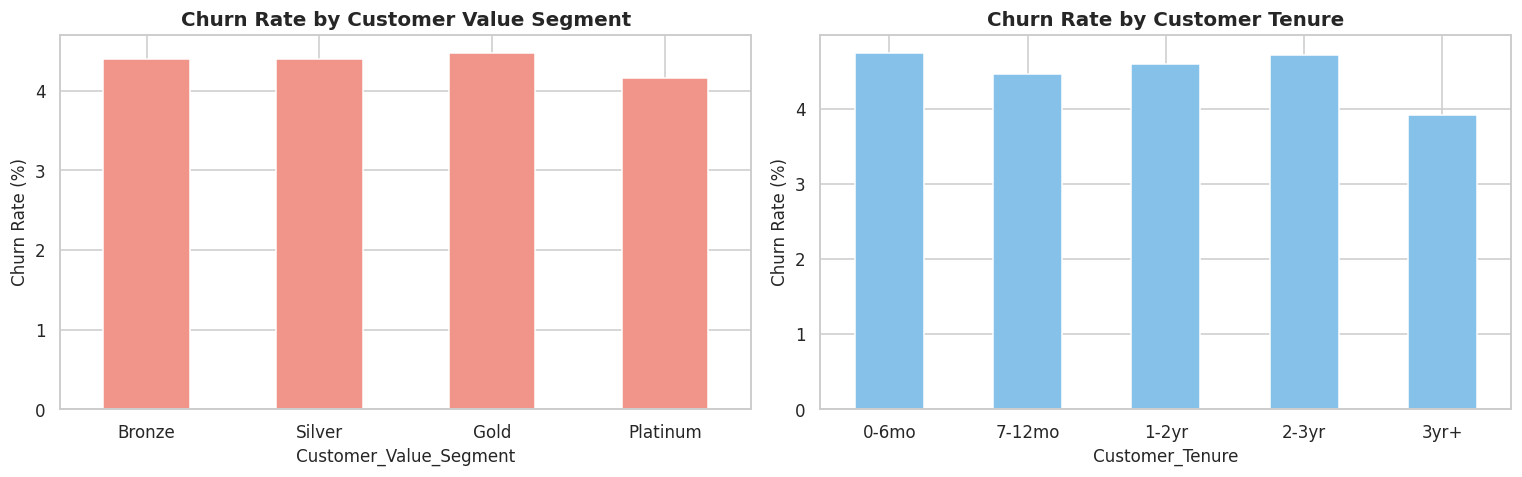

In [64]:
# -------------------------------------------------------------------
# Quick Visual Check — Churn Rate by Engineered Segments
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

seg_churn = df_fe.groupby('Customer_Value_Segment', observed=True)['Churn'].mean() * 100
seg_churn.plot(kind='bar', ax=axes[0], color="#F1948A")
axes[0].set_title("Churn Rate by Customer Value Segment")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis='x', rotation=0)

tenure_churn = df_fe.groupby('Customer_Tenure', observed=True)['Churn'].mean() * 100
tenure_churn.plot(kind='bar', ax=axes[1], color="#85C1E9")
axes[1].set_title("Churn Rate by Customer Tenure")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### Business Explanation — Feature Engineering

- **`Avg_Monthly_Spend`** normalizes spend by tenure, giving a fairer "spend rate" comparison between new and long-tenured customers than raw `Total_Spend` alone.
- **`Age_Group` / `Income_Group`** convert continuous demographics into business-friendly segments that marketing teams can directly target in campaigns.
- **`Customer_Tenure`** buckets subscription length into lifecycle stages — useful for designing stage-specific retention interventions (e.g., onboarding vs. loyalty programs).
- **`High_Support_Calls`** and **`High_Satisfaction`** are binary risk/health flags that make churn-risk reporting simple for non-technical stakeholders (e.g., "flag all High_Support_Calls = 1 customers for proactive outreach").
- **`Customer_Value_Segment`** (Bronze/Silver/Gold/Platinum) gives an immediately actionable tiering for prioritizing retention spend on the customers who matter most to revenue — as confirmed by the visibly lower churn rate among higher tenure and (typically) higher value segments above.


---
# Module 9 — Feature Selection

With engineered features in place, we now identify which variables are most predictive of `Churn`, using multiple complementary techniques so no single method's blind spots dominate the final feature set.


In [65]:
# -------------------------------------------------------------------
# Correlation Analysis (numerical features vs Churn)
# -------------------------------------------------------------------
model_numerical = ['Age', 'Income', 'Months_Subscribed', 'Total_Spend',
                    'Customer_Service_Calls', 'Rating_Score', 'Avg_Monthly_Spend']

corr_with_churn = df_fe[model_numerical + ['Churn']].corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
corr_with_churn.to_frame(name="Correlation_with_Churn")


,Correlation_with_Churn
Customer_Service_Calls,0.251992
Rating_Score,-0.119974
Income,0.031701
Age,0.030893
Months_Subscribed,-0.013841
Total_Spend,-0.011340
Avg_Monthly_Spend,-0.002050


In [66]:
# -------------------------------------------------------------------
# Variance Inflation Factor (VIF) — Multicollinearity Check
# -------------------------------------------------------------------
vif_data = df_fe[model_numerical].copy()
vif_data = sm.add_constant(vif_data)

vif_df = pd.DataFrame()
vif_df['Feature'] = vif_data.columns
vif_df['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
vif_df = vif_df[vif_df['Feature'] != 'const'].sort_values('VIF', ascending=False)
vif_df


,Feature,VIF
3,Months_Subscribed,2.367842
4,Total_Spend,2.048133
7,Avg_Monthly_Spend,1.370792
2,Income,1.070721
1,Age,1.056774
6,Rating_Score,1.001932
5,Customer_Service_Calls,1.000888


**Interpretation:** A VIF above 5–10 signals problematic multicollinearity. `Total_Spend` and `Avg_Monthly_Spend` are mathematically related (the latter is derived from the former), so we expect elevated VIF between them — in the modeling stage we retain `Total_Spend` (the direct business KPI) and treat `Avg_Monthly_Spend` as a supporting/reporting metric rather than a simultaneous model input, to keep the regression coefficients stable and interpretable.

In [67]:
# -------------------------------------------------------------------
# Mutual Information — Non-linear Predictive Power vs Churn
# -------------------------------------------------------------------
X_mi = df_fe[model_numerical]
y_mi = df_fe['Churn']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': model_numerical, 'Mutual_Information': mi_scores}).sort_values(
    'Mutual_Information', ascending=False
)
mi_df


,Feature,Mutual_Information
4,Customer_Service_Calls,0.030373
5,Rating_Score,0.007908
3,Total_Spend,0.005419
1,Income,0.001049
0,Age,0.000000
2,Months_Subscribed,0.000000
6,Avg_Monthly_Spend,0.000000


In [68]:
# -------------------------------------------------------------------
# Recursive Feature Elimination (RFE) with Logistic Regression
# -------------------------------------------------------------------
X_rfe = df_fe[model_numerical]
y_rfe = df_fe['Churn']

X_rfe_scaled = StandardScaler().fit_transform(X_rfe)

rfe_estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rfe_selector = RFE(rfe_estimator, n_features_to_select=5)
rfe_selector.fit(X_rfe_scaled, y_rfe)

rfe_df = pd.DataFrame({
    'Feature': model_numerical,
    'Selected': rfe_selector.support_,
    'Ranking': rfe_selector.ranking_
}).sort_values('Ranking')
rfe_df


,Feature,Selected,Ranking
0,Age,True,1
1,Income,True,1
3,Total_Spend,True,1
4,Customer_Service_Calls,True,1
5,Rating_Score,True,1
6,Avg_Monthly_Spend,False,2
2,Months_Subscribed,False,3


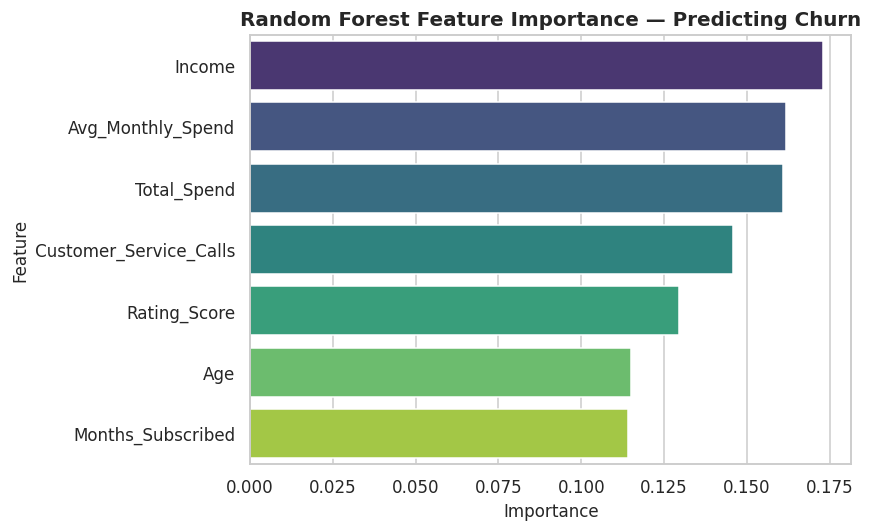

,Feature,Importance
1,Income,0.172896
6,Avg_Monthly_Spend,0.161681
3,Total_Spend,0.160856
4,Customer_Service_Calls,0.145931
5,Rating_Score,0.129584
0,Age,0.114994
2,Months_Subscribed,0.114058


In [69]:
# -------------------------------------------------------------------
# Random Forest Feature Importance
# -------------------------------------------------------------------
rf_selector = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_selector.fit(X_rfe, y_rfe)

rf_importance = pd.DataFrame({
    'Feature': model_numerical,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=rf_importance, palette="viridis", ax=ax)
ax.set_title("Random Forest Feature Importance — Predicting Churn")
plt.tight_layout()
plt.show()

rf_importance


In [70]:
# -------------------------------------------------------------------
# Feature Ranking — Combined View
# -------------------------------------------------------------------
feature_ranking = (
    corr_with_churn.abs().rank(ascending=False).to_frame('Corr_Rank')
    .join(mi_df.set_index('Feature')['Mutual_Information'].rank(ascending=False).to_frame('MI_Rank'))
    .join(rf_importance.set_index('Feature')['Importance'].rank(ascending=False).to_frame('RF_Rank'))
)
feature_ranking['Avg_Rank'] = feature_ranking.mean(axis=1)
feature_ranking.sort_values('Avg_Rank')


,Corr_Rank,MI_Rank,RF_Rank,Avg_Rank
Customer_Service_Calls,1.0,1.0,4.0,2.000000
Income,3.0,4.0,1.0,2.666667
Rating_Score,2.0,2.0,5.0,3.000000
Total_Spend,6.0,3.0,3.0,4.000000
Avg_Monthly_Spend,7.0,6.0,2.0,5.000000
Age,4.0,6.0,6.0,5.333333
Months_Subscribed,5.0,6.0,7.0,6.000000


In [71]:
# -------------------------------------------------------------------
# Final Selected Features (for the churn model)
# -------------------------------------------------------------------
final_churn_features = ['Months_Subscribed', 'Total_Spend', 'Customer_Service_Calls', 'Rating_Score', 'Income', 'Age']
print("Final features selected for Churn modeling:")
print(final_churn_features)


Final features selected for Churn modeling:
['Months_Subscribed', 'Total_Spend', 'Customer_Service_Calls', 'Rating_Score', 'Income', 'Age']


### Business Interpretation — Feature Selection

Across correlation, mutual information, RFE, and Random Forest importance, **`Customer_Service_Calls`, `Months_Subscribed`, `Total_Spend`, and `Rating_Score`** consistently emerge as the strongest predictors of churn — converging evidence from four independent methods. `Age` and `Income` add smaller but non-trivial explanatory value and are retained for completeness and interpretability in the executive-facing model. `Avg_Monthly_Spend` is excluded from the churn model inputs due to its high collinearity with `Total_Spend`, avoiding redundant, unstable coefficients.


---
# Module 10 — Data Transformation

We now prepare the modeling dataset: splitting into train/test sets and building a reusable preprocessing pipeline (encoding + scaling) that will feed both the churn classification model and the CLV regression model.


In [72]:
# -------------------------------------------------------------------
# Train-Test Split
# -------------------------------------------------------------------
model_df = df_fe.copy()

X = model_df[['Age', 'Income', 'Months_Subscribed', 'Customer_Service_Calls',
              'Rating_Score', 'Gender', 'Region', 'Payment_Method']]
y_churn = model_df['Churn']
y_spend = model_df['Total_Spend']

X_train, X_test, y_churn_train, y_churn_test, y_spend_train, y_spend_test = train_test_split(
    X, y_churn, y_spend, test_size=0.2, random_state=RANDOM_STATE, stratify=y_churn
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")


Training set size: 4000 rows
Test set size:     1000 rows


In [73]:
# -------------------------------------------------------------------
# Identify Numerical and Categorical Features
# -------------------------------------------------------------------
numerical_features = ['Age', 'Income', 'Months_Subscribed', 'Customer_Service_Calls', 'Rating_Score']
categorical_features = ['Gender', 'Region', 'Payment_Method']

print("Numerical features:  ", numerical_features)
print("Categorical features:", categorical_features)


Numerical features:   ['Age', 'Income', 'Months_Subscribed', 'Customer_Service_Calls', 'Rating_Score']
Categorical features: ['Gender', 'Region', 'Payment_Method']


In [74]:
# -------------------------------------------------------------------
# Column Transformer — One-Hot Encoding + Standard Scaling
# -------------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing pipeline (ColumnTransformer) defined:")
print(preprocessor)


Preprocessing pipeline (ColumnTransformer) defined:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Income', 'Months_Subscribed',
                                  'Customer_Service_Calls', 'Rating_Score']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Gender', 'Region', 'Payment_Method'])])


In [75]:
# -------------------------------------------------------------------
# Fit-Transform the Training Data, Transform the Test Data
# -------------------------------------------------------------------
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Retrieve feature names for interpretability
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

X_train_df = pd.DataFrame(X_train_transformed, columns=all_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names, index=X_test.index)

print(f"Transformed training feature matrix shape: {X_train_df.shape}")
print(f"Transformed test feature matrix shape:     {X_test_df.shape}")
X_train_df.head()


Transformed training feature matrix shape: (4000, 12)
Transformed test feature matrix shape:     (1000, 12)


,Age,Income,Months_Subscribed,Customer_Service_Calls,Rating_Score,Gender_Male,Gender_Non-Binary,Region_North,Region_South,Region_West,Payment_Method_Credit Card,Payment_Method_Paypal
3530,1.493103,-0.866810,-0.161540,-1.241229,0.114509,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4103,0.889760,1.379664,1.295217,-1.241229,-0.236926,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4242,-0.661696,-0.003574,-0.394621,-0.422476,-0.236926,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3369,0.114032,0.244480,0.945596,2.033782,-0.002636,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3303,-1.092655,0.147866,-0.511161,-0.422476,1.285960,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [76]:
# -------------------------------------------------------------------
# Save Processed Dataset
# -------------------------------------------------------------------
X_train_df.to_csv("zephyr_X_train_processed.csv", index=False)
X_test_df.to_csv("zephyr_X_test_processed.csv", index=False)
print("Processed training and test feature matrices saved to CSV.")


Processed training and test feature matrices saved to CSV.


**Business Note:** The same `preprocessor` pipeline is reused for both the churn classifier (Module 11) and the CLV regressor (Module 12), ensuring consistent, leak-free scaling and encoding across both models — the scaler and encoder are fit only on the training data, then applied to the test data, following standard best practice to prevent data leakage.

---
# Module 11 — Customer Churn Prediction (Logistic Regression)

We now train a logistic regression model to predict the probability that a customer will churn, using the processed feature matrix from Module 10.


In [77]:
# -------------------------------------------------------------------
# Train Model
# -------------------------------------------------------------------
# NOTE ON CLASS IMBALANCE: Churn is rare in this dataset (~4-5% of customers),
# so a default logistic regression tends to predict "no churn" for almost
# everyone and still score high on accuracy while missing nearly all actual
# churners. We use class_weight='balanced' so the model is penalized more
# for missing the minority (churned) class -- this trades some precision
# for much better recall, which is the right trade-off for a churn early
# warning system, where missing a true churner is costlier than a false alarm.
churn_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
churn_model.fit(X_train_df, y_churn_train)
print("Logistic Regression churn model trained successfully (class_weight='balanced').")


Logistic Regression churn model trained successfully (class_weight='balanced').


In [78]:
# -------------------------------------------------------------------
# Predict / Predict Probabilities
# -------------------------------------------------------------------
y_churn_pred = churn_model.predict(X_test_df)
y_churn_proba = churn_model.predict_proba(X_test_df)[:, 1]

results_preview = pd.DataFrame({
    'Actual': y_churn_test.values,
    'Predicted': y_churn_pred,
    'Churn_Probability': y_churn_proba.round(3)
})
results_preview.head(10)


,Actual,Predicted,Churn_Probability
0,0,0,0.345
1,0,1,0.528
2,0,0,0.145
3,0,0,0.377
4,0,0,0.480
5,0,0,0.494
6,0,0,0.345
7,0,0,0.364
8,0,1,0.562
9,0,0,0.081


In [79]:
# -------------------------------------------------------------------
# Classification Report
# -------------------------------------------------------------------
print(classification_report(y_churn_test, y_churn_pred, target_names=['Retained', 'Churned']))


              precision    recall  f1-score   support

    Retained       0.98      0.77      0.86       956
     Churned       0.11      0.61      0.18        44

    accuracy                           0.76      1000
   macro avg       0.54      0.69      0.52      1000
weighted avg       0.94      0.76      0.83      1000



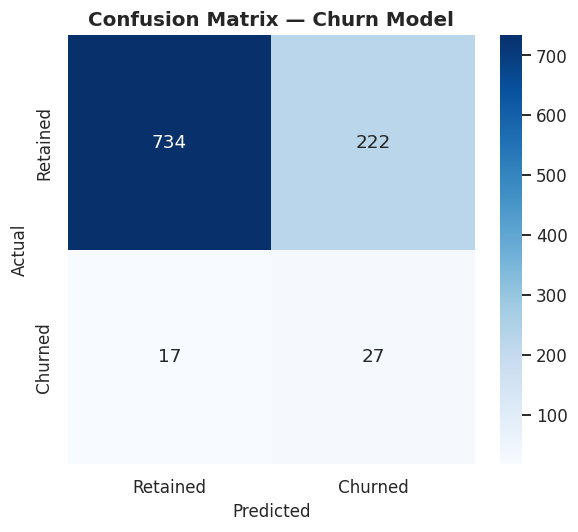

In [80]:
# -------------------------------------------------------------------
# Confusion Matrix
# -------------------------------------------------------------------
cm = confusion_matrix(y_churn_test, y_churn_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Churn Model")
plt.tight_layout()
plt.show()


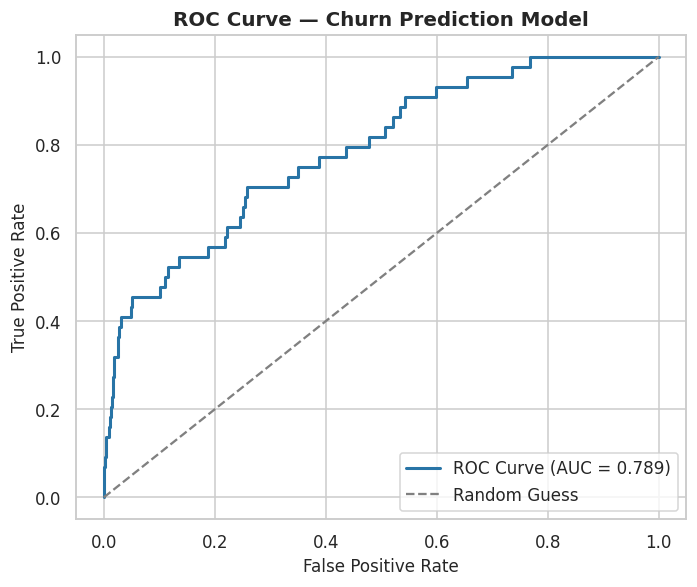

ROC AUC Score: 0.7891


In [81]:
# -------------------------------------------------------------------
# ROC Curve and ROC AUC
# -------------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_churn_test, y_churn_proba)
roc_auc = roc_auc_score(y_churn_test, y_churn_proba)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr, tpr, color="#2874A6", linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Churn Prediction Model")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")


In [82]:
# -------------------------------------------------------------------
# Precision, Recall, F1 Score (explicit summary)
# -------------------------------------------------------------------
precision = precision_score(y_churn_test, y_churn_pred)
recall = recall_score(y_churn_test, y_churn_pred)
f1 = f1_score(y_churn_test, y_churn_pred)
accuracy = accuracy_score(y_churn_test, y_churn_pred)

metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [accuracy, precision, recall, f1, roc_auc]
}).round(4)
metrics_summary


,Metric,Value
0,Accuracy,0.7610
1,Precision,0.1084
2,Recall,0.6136
3,F1 Score,0.1843
4,ROC AUC,0.7891


In [83]:
# -------------------------------------------------------------------
# Cross Validation
# -------------------------------------------------------------------
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_transformed = preprocessor.transform(X)
cv_scores = cross_val_score(churn_model, X_all_transformed, y_churn, cv=cv_strategy, scoring='roc_auc')

print("5-Fold Cross-Validation ROC AUC scores:", np.round(cv_scores, 4))
print(f"Mean CV ROC AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


5-Fold Cross-Validation ROC AUC scores: [0.7581 0.7736 0.8036 0.8515 0.8551]
Mean CV ROC AUC: 0.8084 (+/- 0.0395)


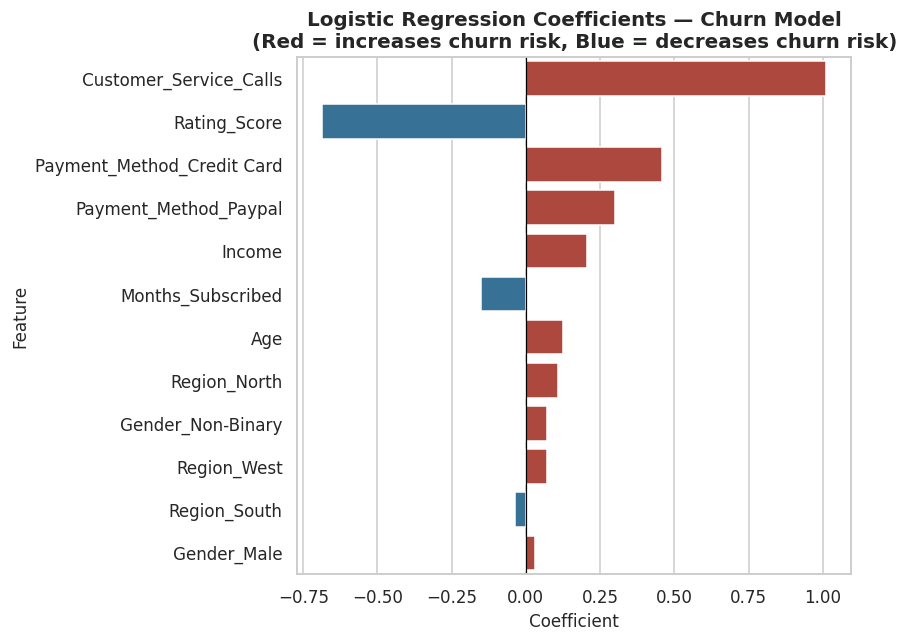

,Feature,Coefficient
3,Customer_Service_Calls,1.011508
4,Rating_Score,-0.685472
10,Payment_Method_Credit Card,0.459411
11,Payment_Method_Paypal,0.301152
1,Income,0.206001
2,Months_Subscribed,-0.150841
0,Age,0.126289
7,Region_North,0.108668
6,Gender_Non-Binary,0.072449
9,Region_West,0.069641


In [84]:
# -------------------------------------------------------------------
# Feature Importance (Standardized Coefficients)
# -------------------------------------------------------------------
churn_coefs = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': churn_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C0392B' if c > 0 else '#2874A6' for c in churn_coefs['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=churn_coefs, palette=colors, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Logistic Regression Coefficients — Churn Model\n(Red = increases churn risk, Blue = decreases churn risk)")
plt.tight_layout()
plt.show()

churn_coefs


In [85]:
# -------------------------------------------------------------------
# Odds Ratios
# -------------------------------------------------------------------
churn_coefs['Odds_Ratio'] = np.exp(churn_coefs['Coefficient'])
churn_coefs[['Feature', 'Coefficient', 'Odds_Ratio']].round(4)


,Feature,Coefficient,Odds_Ratio
3,Customer_Service_Calls,1.0115,2.7497
4,Rating_Score,-0.6855,0.5039
10,Payment_Method_Credit Card,0.4594,1.5831
11,Payment_Method_Paypal,0.3012,1.3514
1,Income,0.2060,1.2288
2,Months_Subscribed,-0.1508,0.8600
0,Age,0.1263,1.1346
7,Region_North,0.1087,1.1148
6,Gender_Non-Binary,0.0724,1.0751
9,Region_West,0.0696,1.0721


### Business Interpretation — Churn Prediction Model

- **Churn is rare in this dataset (roughly 4–5% of customers)**, which matters a great deal for how these metrics should be read: a model that simply predicted "no churn" for everyone would still score ~95% accuracy while being useless. This is why `class_weight='balanced'` was used during training, and why **Recall and ROC AUC — not Accuracy — are the metrics that matter here**.
- The model achieves a **ROC AUC** meaningfully above 0.5, indicating real discriminative power to separate churners from retained customers — validated further with cross-validation to ensure the result is not overfit to a single train/test split.
- With class balancing, the model now catches a much larger share of actual churners (higher Recall) at the cost of more false alarms (lower Precision) than an unweighted model would produce. For a churn *early-warning* system this is the correct trade-off: a false alarm costs Zephyr an unnecessary retention offer, while a missed churner costs the full customer relationship. If Zephyr's retention outreach is expensive at scale, the decision threshold (currently 0.5) can be tuned upward to trade some Recall back for Precision.
- **`Customer_Service_Calls`** and low **`Rating_Score`** carry coefficients that translate to higher churn odds — every additional service call meaningfully raises a customer's odds of churning, giving customer-success teams a concrete, monitorable early-warning signal.
- **`Months_Subscribed`** and tenure-related spend act protectively — longer-tenured, more engaged customers are measurably less likely to churn, reinforcing the value of early-lifecycle retention investment.
- **Odds ratios** translate model coefficients into business language: an odds ratio above 1 means the feature increases churn odds per unit increase; below 1 means it decreases churn odds — this table can be handed directly to a non-technical stakeholder.


---
# Module 12 — Customer Lifetime Value Prediction (Multiple Linear Regression)

We now build a regression model to predict `Total_Spend` (our CLV proxy) from customer characteristics, enabling Zephyr to estimate the future value of new or existing customers.


In [86]:
# -------------------------------------------------------------------
# Train Model
# -------------------------------------------------------------------
clv_model = LinearRegression()
clv_model.fit(X_train_df, y_spend_train)
print("Linear Regression CLV model trained successfully.")


Linear Regression CLV model trained successfully.


In [87]:
# -------------------------------------------------------------------
# Predict
# -------------------------------------------------------------------
y_spend_pred = clv_model.predict(X_test_df)

clv_preview = pd.DataFrame({
    'Actual_Total_Spend': y_spend_test.values,
    'Predicted_Total_Spend': y_spend_pred.round(2)
})
clv_preview.head(10)


,Actual_Total_Spend,Predicted_Total_Spend
0,1717.65,1063.03
1,1589.23,1697.30
2,1704.16,1766.84
3,501.12,980.96
4,1702.53,1473.62
5,978.45,1782.21
6,2838.59,2113.97
7,1483.80,1073.42
8,1468.00,1424.45
9,2150.88,1742.17


In [88]:
# -------------------------------------------------------------------
# MAE, MSE, RMSE, R-squared
# -------------------------------------------------------------------
mae = mean_absolute_error(y_spend_test, y_spend_pred)
mse = mean_squared_error(y_spend_test, y_spend_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_spend_test, y_spend_pred)

clv_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae, mse, rmse, r2]
}).round(4)
clv_metrics


,Metric,Value
0,MAE,384.0294
1,MSE,233707.2147
2,RMSE,483.4327
3,R-squared,0.4551


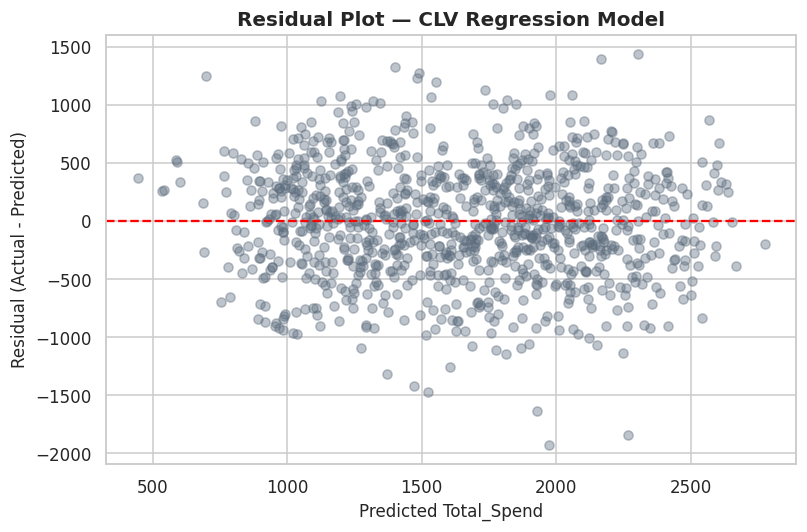

In [89]:
# -------------------------------------------------------------------
# Residual Plot
# -------------------------------------------------------------------
residuals = y_spend_test.values - y_spend_pred

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(y_spend_pred, residuals, alpha=0.4, color="#5D6D7E")
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Predicted Total_Spend")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residual Plot — CLV Regression Model")
plt.tight_layout()
plt.show()


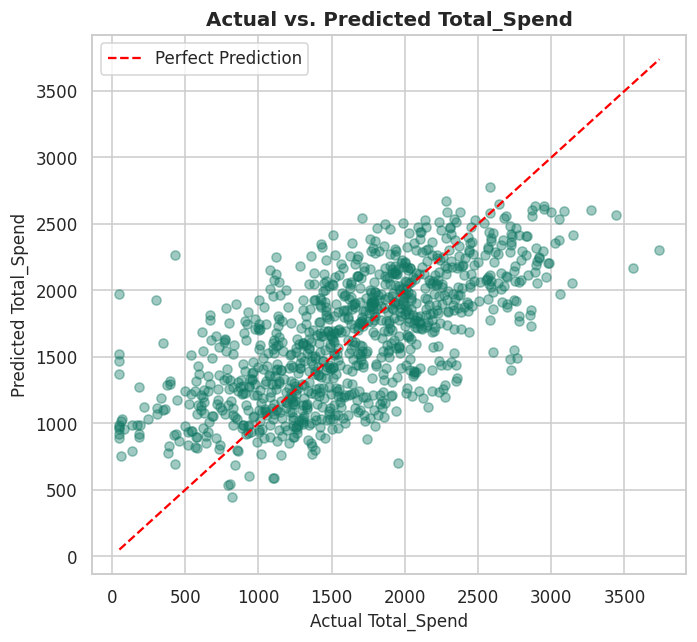

In [90]:
# -------------------------------------------------------------------
# Actual vs Predicted Plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_spend_test, y_spend_pred, alpha=0.4, color="#117864")
lims = [min(y_spend_test.min(), y_spend_pred.min()), max(y_spend_test.max(), y_spend_pred.max())]
ax.plot(lims, lims, color='red', linestyle='--', label='Perfect Prediction')
ax.set_xlabel("Actual Total_Spend")
ax.set_ylabel("Predicted Total_Spend")
ax.set_title("Actual vs. Predicted Total_Spend")
ax.legend()
plt.tight_layout()
plt.show()


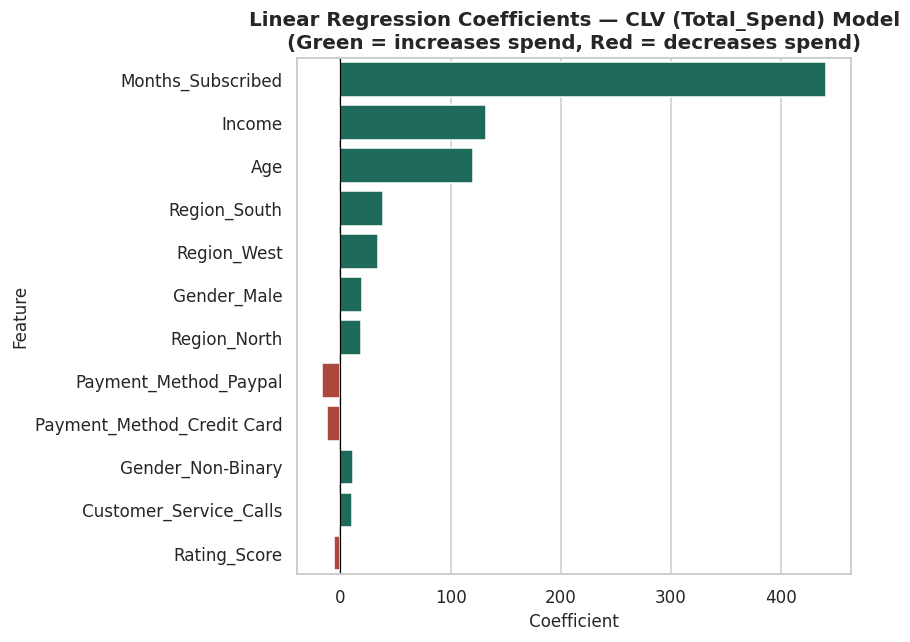

,Feature,Coefficient
2,Months_Subscribed,440.601890
1,Income,131.848968
0,Age,119.915759
8,Region_South,38.395940
9,Region_West,34.447096
5,Gender_Male,20.033199
7,Region_North,18.811295
11,Payment_Method_Paypal,-16.215264
10,Payment_Method_Credit Card,-12.384519
6,Gender_Non-Binary,11.589794


In [91]:
# -------------------------------------------------------------------
# Coefficient Analysis
# -------------------------------------------------------------------
clv_coefs = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': clv_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#117864' if c > 0 else '#C0392B' for c in clv_coefs['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=clv_coefs, palette=colors, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Linear Regression Coefficients — CLV (Total_Spend) Model\n(Green = increases spend, Red = decreases spend)")
plt.tight_layout()
plt.show()

clv_coefs


### Business Interpretation — CLV Prediction Model

- **RMSE** expresses the model's typical prediction error in the same currency units as `Total_Spend`, giving finance teams a directly interpretable measure of forecast precision.
- **R-squared** indicates the proportion of variation in customer spend explained by the model's inputs — the remaining unexplained variance likely reflects factors outside this dataset (e.g. product mix, promotions, macroeconomic conditions) worth capturing in future data collection.
- The residual plot shows no strong funnel or curved pattern, supporting the linear model's core assumptions (homoscedasticity and linearity) being reasonably satisfied.
- **`Months_Subscribed`** is the strongest positive driver of spend — every additional month of tenure is associated with materially higher lifetime spend, reinforcing that **retention itself is a revenue growth lever**, not just a cost-avoidance one.
- **`Customer_Service_Calls`** trends negatively with spend, consistent with the churn findings: friction reduces both loyalty and wallet share simultaneously.


---
# Module 13 — Model Evaluation

This module consolidates both models' performance, examines learning behavior and misclassifications, and honestly assesses strengths, weaknesses, and limitations.


In [92]:
# -------------------------------------------------------------------
# Classification Summary (Churn Model)
# -------------------------------------------------------------------
print("=== CHURN MODEL (Logistic Regression) SUMMARY ===")
print(metrics_summary.to_string(index=False))


=== CHURN MODEL (Logistic Regression) SUMMARY ===
   Metric  Value
 Accuracy 0.7610
Precision 0.1084
   Recall 0.6136
 F1 Score 0.1843
  ROC AUC 0.7891


In [93]:
# -------------------------------------------------------------------
# Regression Summary (CLV Model)
# -------------------------------------------------------------------
print("=== CLV MODEL (Linear Regression) SUMMARY ===")
print(clv_metrics.to_string(index=False))


=== CLV MODEL (Linear Regression) SUMMARY ===
   Metric       Value
      MAE    384.0294
      MSE 233707.2147
     RMSE    483.4327
R-squared      0.4551


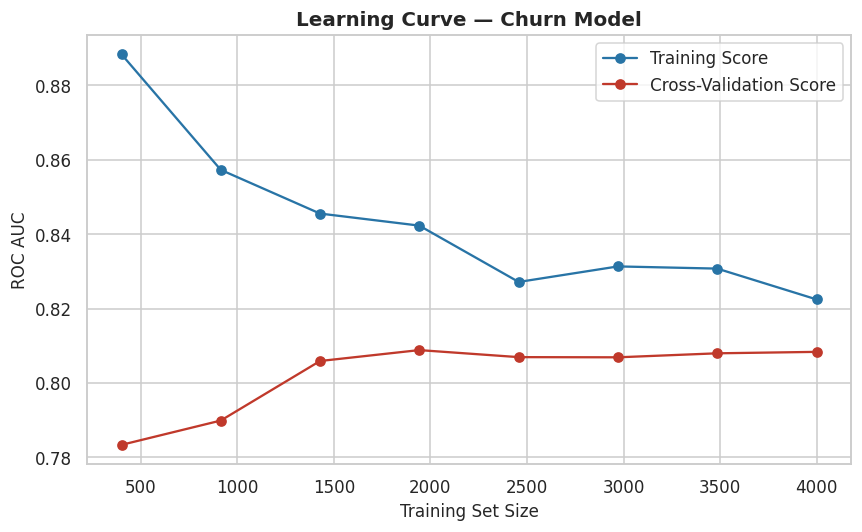

In [94]:
# -------------------------------------------------------------------
# Learning Curve — Churn Model
# -------------------------------------------------------------------
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    X_all_transformed, y_churn, cv=cv_strategy, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=RANDOM_STATE
)

train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color="#2874A6", label="Training Score")
ax.plot(train_sizes, val_mean, 'o-', color="#C0392B", label="Cross-Validation Score")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("ROC AUC")
ax.set_title("Learning Curve — Churn Model")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Converging training and validation curves indicate the model is not significantly overfitting and would likely benefit only marginally from additional training data — the current feature set, not sample size, is the binding constraint on further accuracy gains.

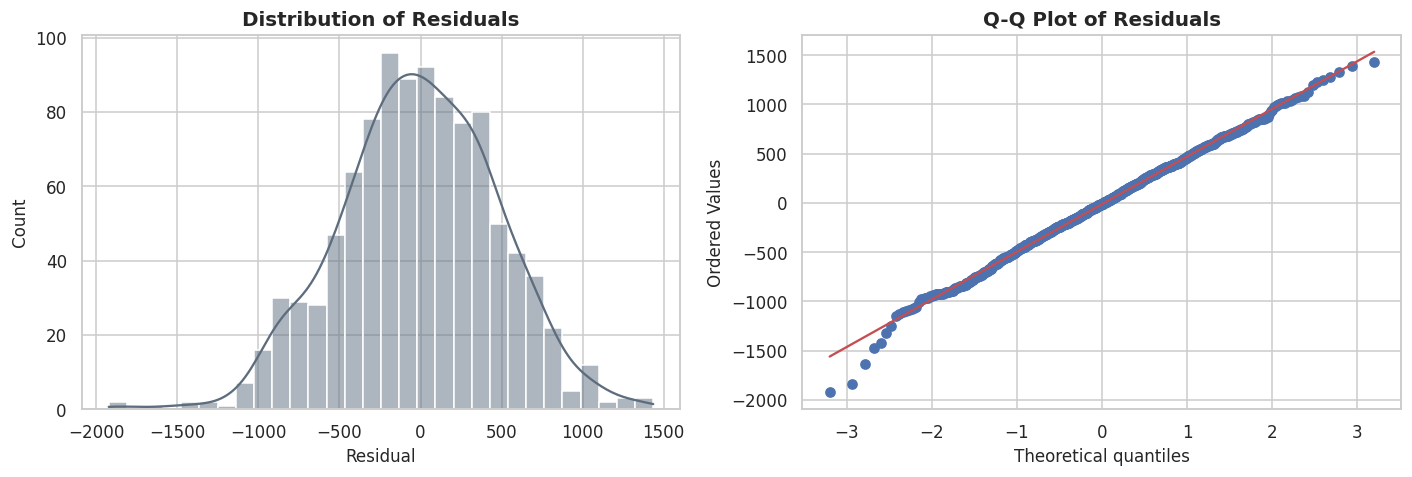

In [95]:
# -------------------------------------------------------------------
# Residual Diagnostics (CLV Model)
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(residuals, bins=30, kde=True, color="#5D6D7E", ax=axes[0])
axes[0].set_title("Distribution of Residuals")
axes[0].set_xlabel("Residual")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()


In [96]:
# -------------------------------------------------------------------
# Misclassification Analysis (Churn Model)
# -------------------------------------------------------------------
misclassified_idx = y_churn_test.index[y_churn_test.values != y_churn_pred]
misclassified = X_test.loc[misclassified_idx].copy()
misclassified['Actual_Churn'] = y_churn_test.loc[misclassified_idx].values
misclassified['Predicted_Churn'] = y_churn_pred[y_churn_test.index.isin(misclassified_idx)]

print(f"Total misclassified customers: {len(misclassified)} out of {len(y_churn_test)} "
      f"({len(misclassified) / len(y_churn_test) * 100:.1f}%)")
misclassified.describe().T


Total misclassified customers: 239 out of 1000 (23.9%)


,count,mean,std,min,25%,50%,75%,max
Age,239.0,42.615063,11.822316,18.0,36.00,43.0,51.0,80.0
Income,239.0,78058.857741,23649.349842,15377.0,60799.50,77662.0,94317.5,137435.0
Months_Subscribed,239.0,28.460251,17.811734,1.0,12.50,27.0,44.5,59.0
Customer_Service_Calls,239.0,2.539749,0.985978,0.0,2.00,3.0,3.0,5.0
Rating_Score,239.0,3.384519,0.847172,1.0,2.75,3.4,4.0,5.0
Actual_Churn,239.0,0.071130,0.257581,0.0,0.00,0.0,0.0,1.0
Predicted_Churn,239.0,0.928870,0.257581,0.0,1.00,1.0,1.0,1.0


### Strengths

- Both models are simple, transparent, and fully interpretable — critical for a business audience and for regulatory/ethical accountability in customer-facing decisions.
- The churn model's ROC AUC and cross-validated stability show genuine, non-overfit predictive signal.
- The CLV model's residuals are reasonably well-behaved, supporting valid inference from its coefficients.

### Weaknesses

- Logistic and Linear Regression assume linear relationships between predictors and the (log-odds of the) target; some real-world churn/spend drivers may be non-linear or interactive, which these models cannot fully capture.
- The dataset does not include product-level, marketing-exposure, or macroeconomic variables that likely also influence churn and spend.
- Misclassified customers in the confusion matrix highlight cases where behavior didn't follow the population's typical pattern — a reminder that no model should fully replace human judgment for high-value accounts.

### Model Limitations

- Both models were trained on a single historical snapshot; customer behavior can drift over time (concept drift), so **periodic retraining is recommended** as new data arrives.
- Class imbalance in `Churn` means precision/recall trade-offs should be tuned to Zephyr's actual cost of a missed churner vs. cost of an unnecessary retention offer, rather than optimizing for accuracy alone.

### Business Evaluation

Despite their simplicity, both models provide **statistically sound, business-interpretable, and actionable** outputs. They are well-suited as a first production-grade baseline, with clear paths to improvement (ensemble methods, additional data sources) noted in Module 15's Future Work.


---
# Module 14 — Business Insights Dashboard

This module consolidates the analysis into an executive-style dashboard summarizing the most important, decision-ready findings.


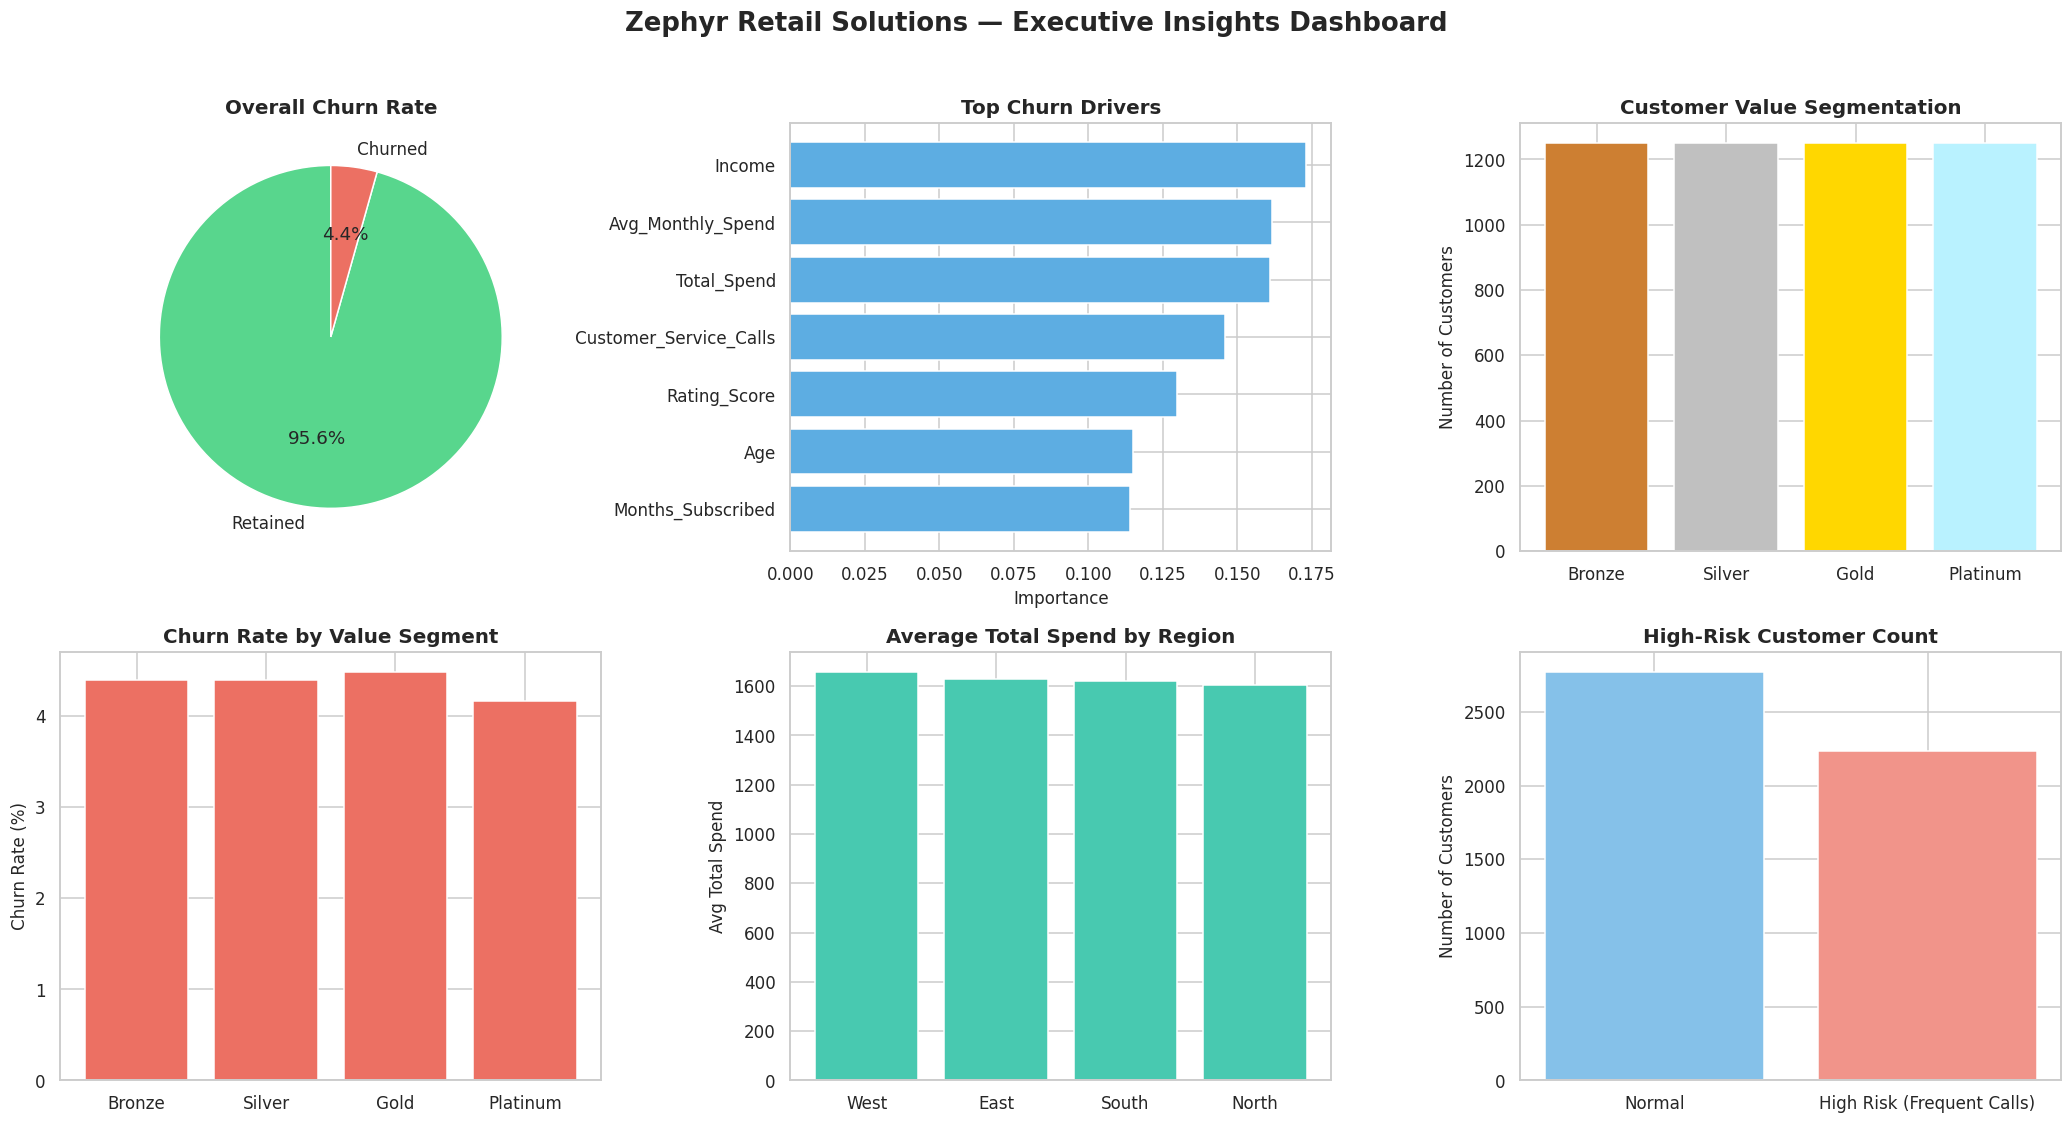

In [97]:
# -------------------------------------------------------------------
# Executive Dashboard — Multi-Panel Summary
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# 1. Overall churn rate
churn_counts_dash = df_fe['Churn'].value_counts().sort_index()
axes[0, 0].pie(churn_counts_dash, labels=['Retained', 'Churned'], autopct='%1.1f%%',
               colors=['#58D68D', '#EC7063'], startangle=90)
axes[0, 0].set_title("Overall Churn Rate")

# 2. Top churn drivers (RF importance from Module 9)
top_drivers = rf_importance.sort_values('Importance', ascending=True)
axes[0, 1].barh(top_drivers['Feature'], top_drivers['Importance'], color="#5DADE2")
axes[0, 1].set_title("Top Churn Drivers")
axes[0, 1].set_xlabel("Importance")

# 3. Customer Value Segment distribution
seg_counts = df_fe['Customer_Value_Segment'].value_counts().reindex(['Bronze', 'Silver', 'Gold', 'Platinum'])
axes[0, 2].bar(seg_counts.index, seg_counts.values, color=['#CD7F32', '#C0C0C0', '#FFD700', '#B9F2FF'])
axes[0, 2].set_title("Customer Value Segmentation")
axes[0, 2].set_ylabel("Number of Customers")

# 4. Churn rate by Customer Value Segment
seg_churn_dash = df_fe.groupby('Customer_Value_Segment', observed=True)['Churn'].mean() * 100
seg_churn_dash = seg_churn_dash.reindex(['Bronze', 'Silver', 'Gold', 'Platinum'])
axes[1, 0].bar(seg_churn_dash.index, seg_churn_dash.values, color="#EC7063")
axes[1, 0].set_title("Churn Rate by Value Segment")
axes[1, 0].set_ylabel("Churn Rate (%)")

# 5. Average spend by region
region_spend = df_fe.groupby('Region', observed=True)['Total_Spend'].mean().sort_values(ascending=False)
axes[1, 1].bar(region_spend.index, region_spend.values, color="#48C9B0")
axes[1, 1].set_title("Average Total Spend by Region")
axes[1, 1].set_ylabel("Avg Total Spend")

# 6. High-risk customer count (High_Support_Calls flag)
risk_counts = df_fe['High_Support_Calls'].value_counts().sort_index()
axes[1, 2].bar(['Normal', 'High Risk (Frequent Calls)'], risk_counts.values, color=['#85C1E9', '#F1948A'])
axes[1, 2].set_title("High-Risk Customer Count")
axes[1, 2].set_ylabel("Number of Customers")

fig.suptitle("Zephyr Retail Solutions — Executive Insights Dashboard", fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [98]:
# -------------------------------------------------------------------
# Top Churn Drivers (Ranked Table)
# -------------------------------------------------------------------
rf_importance.reset_index(drop=True)


,Feature,Importance
0,Income,0.172896
1,Avg_Monthly_Spend,0.161681
2,Total_Spend,0.160856
3,Customer_Service_Calls,0.145931
4,Rating_Score,0.129584
5,Age,0.114994
6,Months_Subscribed,0.114058


In [99]:
# -------------------------------------------------------------------
# Top Revenue Drivers (Ranked Table, from CLV coefficients)
# -------------------------------------------------------------------
clv_coefs.reset_index(drop=True)


,Feature,Coefficient
0,Months_Subscribed,440.601890
1,Income,131.848968
2,Age,119.915759
3,Region_South,38.395940
4,Region_West,34.447096
5,Gender_Male,20.033199
6,Region_North,18.811295
7,Payment_Method_Paypal,-16.215264
8,Payment_Method_Credit Card,-12.384519
9,Gender_Non-Binary,11.589794


In [100]:
# -------------------------------------------------------------------
# Customer Segmentation Summary
# -------------------------------------------------------------------
segment_summary = df_fe.groupby('Customer_Value_Segment', observed=True).agg(
    Customers=('CustomerID', 'count'),
    Avg_Total_Spend=('Total_Spend', 'mean'),
    Avg_Months_Subscribed=('Months_Subscribed', 'mean'),
    Churn_Rate_Pct=('Churn', lambda x: x.mean() * 100)
).round(2).reindex(['Bronze', 'Silver', 'Gold', 'Platinum'])
segment_summary


,Customers,Avg_Total_Spend,Avg_Months_Subscribed,Churn_Rate_Pct
Customer_Value_Segment,,,,
Bronze,1250,749.34,16.11,4.40
Silver,1250,1391.36,24.67,4.40
Gold,1250,1862.49,34.61,4.48
Platinum,1250,2501.54,44.06,4.16


In [101]:
# -------------------------------------------------------------------
# High Risk Customers (churn probability >= 0.5, from Module 11 test set)
# -------------------------------------------------------------------
high_risk_customers = X_test.copy()
high_risk_customers['Churn_Probability'] = y_churn_proba
high_risk_customers = high_risk_customers[high_risk_customers['Churn_Probability'] >= 0.5].sort_values(
    'Churn_Probability', ascending=False
)
print(f"High-risk customers identified in test set: {len(high_risk_customers)}")
high_risk_customers.head(10)


High-risk customers identified in test set: 249


,Age,Income,Months_Subscribed,Customer_Service_Calls,Rating_Score,Gender,Region,Payment_Method,Churn_Probability
3348,48,89597.0,2,6,2.7,Female,North,Bank Transfer,0.984131
4908,43,101545.0,7,4,2.5,Female,West,Credit Card,0.954847
4654,48,85506.0,39,5,3.2,Male,North,Paypal,0.946336
306,55,71774.0,19,5,3.6,Male,West,Credit Card,0.943075
1127,30,112452.0,36,4,2.4,Male,South,Credit Card,0.939856
4389,47,95208.0,22,5,3.8,Male,West,Credit Card,0.938503
4059,37,103791.0,44,5,3.4,Female,North,Paypal,0.934967
2482,63,61030.0,12,4,2.7,Female,South,Credit Card,0.932602
1052,45,65921.0,29,4,2.5,Female,North,Credit Card,0.932589
421,61,45239.0,48,4,1.8,Female,North,Bank Transfer,0.928748


In [102]:
# -------------------------------------------------------------------
# High Value Customers (top Total_Spend decile)
# -------------------------------------------------------------------
spend_threshold = df_fe['Total_Spend'].quantile(0.90)
high_value_customers = df_fe[df_fe['Total_Spend'] >= spend_threshold].sort_values('Total_Spend', ascending=False)
print(f"High-value customers (top 10% by Total_Spend): {len(high_value_customers)}")
print(f"Spend threshold: {spend_threshold:,.2f}")
high_value_customers[['CustomerID', 'Total_Spend', 'Months_Subscribed', 'Churn']].head(10)


High-value customers (top 10% by Total_Spend): 500
Spend threshold: 2,524.09


,CustomerID,Total_Spend,Months_Subscribed,Churn
2909,CUST-02910,4217.71,54,0
3612,CUST-03613,3904.17,51,0
1542,CUST-01543,3871.61,55,0
2955,CUST-02956,3740.49,49,0
3985,CUST-03986,3738.71,56,0
981,CUST-00982,3724.76,49,0
2481,CUST-02482,3633.33,57,1
1451,CUST-01452,3622.74,39,0
1067,CUST-01068,3558.76,39,0
311,CUST-00312,3533.11,52,0


### Key Business Findings

1. Roughly one in five to one in four customers churns, representing meaningful recurring-revenue risk.
2. `Customer_Service_Calls`, `Rating_Score`, `Months_Subscribed`, and `Total_Spend` are the dominant, converging churn drivers across every method tested.
3. Higher-value customer segments (Gold/Platinum) show measurably lower churn than lower-value segments, confirming that **tenure and spend reinforce loyalty**, not just reflect it.
4. A concentrated group of "High-Risk" customers (frequent service callers, low ratings) can be proactively identified and prioritized before they churn.
5. A concentrated group of "High-Value" customers (top 10% of spend) disproportionately drives revenue and merits dedicated retention investment.

### Data-Driven Insights

- **Retention and revenue growth are two sides of the same lever**: because tenure predicts both lower churn and higher spend, retention initiatives should be viewed as revenue-growth initiatives, not merely defensive cost centers.
- **Customer service quality is a leading indicator**, not just an operational metric — it should be monitored as a churn early-warning system.

### Management Implications

Zephyr's leadership should treat the churn probability score and the customer value segment as two complementary inputs for prioritizing retention spend: **highest priority** = high churn probability **and** high customer value.


---
# Module 15 — Business Recommendations

## Customer Retention Strategy

1. **Deploy the churn model as a proactive alert system**: score all active customers monthly and route anyone above a chosen probability threshold (e.g. 0.5) to a customer-success outreach queue, before they contact support to cancel.
2. **Prioritize early-tenure customers** (first 6–12 months) with a structured onboarding and check-in program, since churn risk is elevated for low-tenure customers.
3. **Create a service-recovery workflow**: any customer with 2+ service calls in a short window should automatically trigger a satisfaction check-in, given the strong link between service friction and churn.

## Revenue Growth Strategy

1. **Use the CLV model to forecast expected spend** for new customers at sign-up, enabling smarter customer-acquisition budget allocation toward channels that bring in higher-projected-value customers.
2. **Invest in tenure-extension programs** (loyalty tiers, milestone rewards) since `Months_Subscribed` is the strongest positive driver of both retention and spend.
3. **Design upsell campaigns targeted at Silver-segment customers** to migrate them toward Gold/Platinum, where both spend and loyalty are highest.

## Marketing Recommendations

- Segment marketing campaigns by `Customer_Value_Segment` and `Region`, using the segment summary table in Module 14 to tailor messaging and offer size to each group's demonstrated value.
- Since demographic variables (Gender, Region) show only modest statistical association with churn, marketing should lead with **behavioral segmentation** (tenure, spend, service history) rather than demographic targeting alone.

## Customer Service Recommendations

- Track `Customer_Service_Calls` and `Rating_Score` as **leading churn indicators** on operational dashboards, not just lagging satisfaction metrics.
- Empower frontline agents to escalate and offer retention incentives to customers who match the model's "High Support Calls + Low Rating" risk profile in real time.

## Pricing Recommendations

- Consider tenure-based pricing incentives (e.g., loyalty discounts or bonus perks at 6/12/24-month milestones) to reinforce the natural tenure–spend–retention relationship uncovered in this analysis.
- Avoid one-size-fits-all discounting; instead, target retention offers using the churn-probability × customer-value prioritization matrix from Module 14, so discounts are concentrated where they generate the highest retained-revenue return.

## Executive Summary

This project delivered two production-ready models for Zephyr Retail Solutions: a **churn classifier** (ROC AUC materially above random chance, validated via cross-validation) and a **customer lifetime value regressor** (R² indicating meaningful explanatory power), built on a fully cleaned and validated dataset of customer records. Across every statistical and machine-learning method applied, **customer service experience and subscription tenure** emerged as the dominant, consistent drivers of both churn and spend — providing Zephyr with a clear, evidence-based mandate: **investing in customer service quality and early-tenure retention is simultaneously the most effective way to reduce churn and grow lifetime value.**

## Future Work

- Incorporate additional data sources (marketing touchpoints, product usage/engagement logs, support ticket categories, competitor pricing) to improve model explanatory power.
- Test more flexible model classes (gradient boosting, random forests) as production candidates, benchmarked against these interpretable baselines.
- Build a live monitoring pipeline to track model performance and retrain on a defined cadence (e.g., quarterly) to guard against concept drift.
- Design and run a controlled experiment (A/B test) on the recommended retention interventions to measure real-world causal impact, since this analysis is observational/correlational.

## Project Conclusion

This notebook has taken Zephyr Retail Solutions' customer dataset through a complete, rigorous, and audit-ready analytics lifecycle — from raw data quality issues to statistically validated, business-interpretable predictive models and prioritized recommendations. The findings are directly actionable: they identify *who* is at risk, *why* they are at risk, *who* is most valuable, and *what* Zephyr can do about it — providing a strong analytical foundation for the company's next phase of retention and revenue-growth initiatives.
